<a href="https://colab.research.google.com/github/justin8ty/socmed-health-analysis/blob/main/CDS6214_Data_Science_Fundamentals_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title: Social Media Usage and Mental Health Outcomes

Group: Angeline TT9L C

Members:
1. 1221305792	TAN JIN YI
2. 1211105905	TAN JING YI
3. 1231303310	WONG HUI YEE
4. 1231302445	CHIN LI MING


# 1 Data Pre-processing and Cleaning

In [ ]:
# Import libraries
import numpy as np   # For numerical computations
import pandas as pd  # For data manipulation and analysis

In [ ]:
# Reading the dataset from a CSV file into a DataFrame
df = pd.read_csv('Central_Asia_Social_Media_MentalHealth.csv')

# Displaying the shape of the DataFrame (number of rows and columns)
print(df.shape)

# Displaying the first five rows of the DataFrame
df.head()

(200000, 20)


,Country,Age Group,Gender,Urban/Rural,Daily SM Usage (hrs),Most Used SM Platform,Frequency of SM Use,Likes Received (per post),Comments Received (per post),Shares Received (per post),Peer Comparison Frequency (1-10),Social Anxiety Level (1-10),Socioeconomic Status,Education Level,State,Body Image Impact (1-10),Sleep Quality Impact (1-10),Self Confidence Impact (1-10),Cyberbullying Experience (1-10),Anxiety Levels (1-10)
0,Uzbekistan,18-25,Female,Rural,6.3,Instagram,Weekly,302,56,32,1,6,Middle,Master's,Bukhara,8,9,5,2,7
1,Uzbekistan,18-25,Male,Rural,1.2,Facebook,Weekly,294,80,25,1,6,High,Bachelor's,Namangan,5,1,9,5,3
2,Uzbekistan,36-45,Male,Rural,4.8,Instagram,Monthly,288,20,8,6,3,Low,High School,Samarkand,9,9,4,5,8
3,Turkmenistan,36-45,Female,Rural,1.4,Twitter,Daily,169,1,86,2,7,High,Bachelor's,Dashoguz,5,5,6,7,3
4,Kazakhstan,56-65,Female,Rural,0.8,Twitter,Weekly,371,31,6,5,3,High,Master's,Karaganda,10,7,6,1,10


Explanation: The dataset is read into a DataFrame containing 200,000 rows and 20 columns, and the first five rows are displayed.

In [ ]:
# Checking if there are any missing (null) values in the DataFrame
df.isnull().values.any()

np.False_

Explanation: The result of the missing (null) value check in the DataFrame above is False, indicating that the DataFrame contains no NA values.

In [ ]:
# Checking if there are any duplicate rows in the DataFrame
df.duplicated().any()

np.False_

Explanation: The result of the duplicate rows check in the DataFrame above is False, indicating that the DataFrame contains no duplicate rows.

In [ ]:
# Display the data types of each column in the DataFrame
df.dtypes

,0
Country,object
Age Group,object
Gender,object
Urban/Rural,object
Daily SM Usage (hrs),float64
Most Used SM Platform,object
Frequency of SM Use,object
Likes Received (per post),int64
Comments Received (per post),int64
Shares Received (per post),int64


Explanation: The data types of each column are shown above: object (string), float64 (float), and int64 (integer).

Upon checking, all data types are correctly displayed.

In [ ]:
# Define columns expected to have values between 1 and 10
cols_1_to_10 = [
    "Peer Comparison Frequency (1-10)",
    "Social Anxiety Level (1-10)",
    "Body Image Impact (1-10)",
    "Sleep Quality Impact (1-10)",
    "Self Confidence Impact (1-10)",
    "Cyberbullying Experience (1-10)",
    "Anxiety Levels (1-10)"
]

# Find rows with any values out of range (not between 1 and 10)
out_of_range = df[
    df[cols_1_to_10].apply(lambda row: ((row < 1) | (row > 10)).any(), axis=1)
]

# Print the rows with out-of-range values
print(out_of_range)

Empty DataFrame
Columns: [Country, Age Group, Gender, Urban/Rural, Daily SM Usage (hrs), Most Used SM Platform, Frequency of SM Use, Likes Received (per post), Comments Received (per post), Shares Received (per post), Peer Comparison Frequency (1-10), Social Anxiety Level (1-10), Socioeconomic Status, Education Level, State, Body Image Impact (1-10), Sleep Quality Impact (1-10), Self Confidence Impact (1-10), Cyberbullying Experience (1-10), Anxiety Levels (1-10)]
Index: []


Explanation: The check for rows with out-of-range values in the DataFrame above found no such rows.

The columns are intact and listed, showing that no rows have values outside the range of 1 to 10 in columns with string names.

In [ ]:
# Check unique values in columns to identify typos, inconsistent casing, or extra whitespace
print(df['Country'].unique())
print(df['Age Group'].unique())
print(df['Gender'].unique())
print(df['Urban/Rural'].unique())
print(df['Most Used SM Platform'].unique())
print(df['Frequency of SM Use'].unique())
print(df['Socioeconomic Status'].unique())
print(df['Education Level'].unique())

['Uzbekistan' 'Turkmenistan' 'Kazakhstan' 'Kyrgyzstan' 'Tajikistan']
['18-25' '36-45' '56-65' '26-35' '46-55']
['Female' 'Male']
['Rural' 'Urban']
['Instagram' 'Facebook' 'Twitter' 'TikTok' 'Snapchat']
['Weekly' 'Monthly' 'Daily']
['Middle' 'High' 'Low']
["Master's" "Bachelor's" 'High School' 'PhD']


Explanation: The result above shows that no answers with the same meaning appear due to typos, inconsistent casing, or extra whitespace.

In [ ]:
# Save the current state of the DataFrame to a new CSV file without the index column
df.to_csv("Cleaned_Central_Asia_Social_Media_MentalHealth.csv", index=False)

# Display the DataFrame
df

,Country,Age Group,Gender,Urban/Rural,Daily SM Usage (hrs),Most Used SM Platform,Frequency of SM Use,Likes Received (per post),Comments Received (per post),Shares Received (per post),Peer Comparison Frequency (1-10),Social Anxiety Level (1-10),Socioeconomic Status,Education Level,State,Body Image Impact (1-10),Sleep Quality Impact (1-10),Self Confidence Impact (1-10),Cyberbullying Experience (1-10),Anxiety Levels (1-10)
0,Uzbekistan,18-25,Female,Rural,6.3,Instagram,Weekly,302,56,32,1,6,Middle,Master's,Bukhara,8,9,5,2,7
1,Uzbekistan,18-25,Male,Rural,1.2,Facebook,Weekly,294,80,25,1,6,High,Bachelor's,Namangan,5,1,9,5,3
2,Uzbekistan,36-45,Male,Rural,4.8,Instagram,Monthly,288,20,8,6,3,Low,High School,Samarkand,9,9,4,5,8
3,Turkmenistan,36-45,Female,Rural,1.4,Twitter,Daily,169,1,86,2,7,High,Bachelor's,Dashoguz,5,5,6,7,3
4,Kazakhstan,56-65,Female,Rural,0.8,Twitter,Weekly,371,31,6,5,3,High,Master's,Karaganda,10,7,6,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,Turkmenistan,36-45,Female,Urban,9.2,Instagram,Monthly,486,4,16,7,6,Low,High School,Mary,9,2,4,5,8
199996,Uzbekistan,56-65,Male,Rural,9.0,TikTok,Weekly,240,17,59,1,2,Middle,PhD,Samarkand,4,5,3,7,2
199997,Uzbekistan,18-25,Male,Rural,2.3,TikTok,Weekly,12,31,68,7,5,Middle,High School,Tashkent,8,9,6,7,4
199998,Turkmenistan,56-65,Male,Urban,2.2,Twitter,Weekly,244,69,21,4,7,Low,Master's,Dashoguz,9,4,6,4,8


Explanation: The above dataset is preprocessed and cleaned, then saved as "Cleaned_Central_Asia_Social_Media_MentalHealth.csv" without including the index.

# 2 Exploratory Data Analysis (EDA) and Statistical Study

In [ ]:
!pip install --quiet skrebate

In [ ]:
# Import libraries
import seaborn as sns                                        # Imports seaborn for creating statistical graphics
import matplotlib.pyplot as plt                              # Imports  matplotlib.pyplot for visualizing data
# Import module from library
from scipy import stats                                      # Imports the stats module to perform one_way ANOVA test and t-test
from scipy.stats import f_oneway                             # Imports the one-way ANOVA function from scipy.stats
from scipy.stats import chi2_contingency                     # Imports Chi-square function from scipy.stats
from scipy.stats import spearmanr                            # Imports spearmanr to calculate spearman correlation and p-value
from scipy.stats import pearsonr                             # Imports pearsonr to calculate pearson correlation and p-value
from sklearn.preprocessing import LabelEncoder               # Imports LabelEncoder to encode categorical variable
from sklearn.preprocessing import StandardScaler             # Imports StandardScaler to standardize the data
from sklearn.feature_selection import mutual_info_regression # Imports mutual information to detect any kind of non-lienar relationship with numerical target
from sklearn.feature_selection import mutual_info_classif    # Imports mutual information to detect any kind of non-linear relationship with categorical target
from skrebate import ReliefF                                 # Imports ReliefF to capture feature interations
from sklearn.feature_selection import f_classif              # Imports f_classif to assesses the dependency between features and the categorical target variable
from sklearn.feature_selection import f_regression           # Imports f_regression to assesses the dependency between features and the numerical target variable
from sklearn.preprocessing import MinMaxScaler               # Imports MinMaxScaler to scale the data between 0 and 1

## 2.1 Data Loading

In [ ]:
# Load dataset
df = pd.read_csv('Cleaned_Central_Asia_Social_Media_MentalHealth.csv')

# Display first 5 rows of data
df.head()

,Country,Age Group,Gender,Urban/Rural,Daily SM Usage (hrs),Most Used SM Platform,Frequency of SM Use,Likes Received (per post),Comments Received (per post),Shares Received (per post),Peer Comparison Frequency (1-10),Social Anxiety Level (1-10),Socioeconomic Status,Education Level,State,Body Image Impact (1-10),Sleep Quality Impact (1-10),Self Confidence Impact (1-10),Cyberbullying Experience (1-10),Anxiety Levels (1-10)
0,Uzbekistan,18-25,Female,Rural,6.3,Instagram,Weekly,302,56,32,1,6,Middle,Master's,Bukhara,8,9,5,2,7
1,Uzbekistan,18-25,Male,Rural,1.2,Facebook,Weekly,294,80,25,1,6,High,Bachelor's,Namangan,5,1,9,5,3
2,Uzbekistan,36-45,Male,Rural,4.8,Instagram,Monthly,288,20,8,6,3,Low,High School,Samarkand,9,9,4,5,8
3,Turkmenistan,36-45,Female,Rural,1.4,Twitter,Daily,169,1,86,2,7,High,Bachelor's,Dashoguz,5,5,6,7,3
4,Kazakhstan,56-65,Female,Rural,0.8,Twitter,Weekly,371,31,6,5,3,High,Master's,Karaganda,10,7,6,1,10


## 2.2 Exploratory Data Analysis (EDA)

2.2.1 Dataset Summary

In [ ]:
# Display current dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Country                           200000 non-null  object 
 1   Age Group                         200000 non-null  object 
 2   Gender                            200000 non-null  object 
 3   Urban/Rural                       200000 non-null  object 
 4   Daily SM Usage (hrs)              200000 non-null  float64
 5   Most Used SM Platform             200000 non-null  object 
 6   Frequency of SM Use               200000 non-null  object 
 7   Likes Received (per post)         200000 non-null  int64  
 8   Comments Received (per post)      200000 non-null  int64  
 9   Shares Received (per post)        200000 non-null  int64  
 10  Peer Comparison Frequency (1-10)  200000 non-null  int64  
 11  Social Anxiety Level (1-10)       200000 non-null  i

Explain:  
This dataset contains 200,000 rows with 20 columns that contain variables capturing social media usage behavior, demographic characteristics, and psychological impacts among individuals from Central Asia countries. The dataset includes numerical (Dtype: float64 and int64) and categorical (Dtype: object) features. Every row of each variable has data; thus, all features are non-null.

### 2.2.2 Summary Statistics

In [ ]:
# Describe the numerical features with summary statistics
df.describe().round(3)

,Daily SM Usage (hrs),Likes Received (per post),Comments Received (per post),Shares Received (per post),Peer Comparison Frequency (1-10),Social Anxiety Level (1-10),Body Image Impact (1-10),Sleep Quality Impact (1-10),Self Confidence Impact (1-10),Cyberbullying Experience (1-10),Anxiety Levels (1-10)
count,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.00,200000.000,200000.000,200000.000,200000.000
mean,5.270,249.292,49.415,49.443,5.508,5.494,5.50,5.513,5.501,5.501,5.501
std,2.738,144.339,28.898,28.870,2.873,2.870,2.87,2.868,2.876,2.877,2.876
min,0.500,0.000,0.000,0.000,1.000,1.000,1.00,1.000,1.000,1.000,1.000
25%,2.900,124.000,24.000,24.000,3.000,3.000,3.00,3.000,3.000,3.000,3.000
50%,5.300,249.000,49.000,49.000,6.000,6.000,5.00,6.000,6.000,6.000,6.000
75%,7.600,375.000,74.000,74.000,8.000,8.000,8.00,8.000,8.000,8.000,8.000
max,10.000,499.000,99.000,99.000,10.000,10.000,10.00,10.000,10.000,10.000,10.000


Explain:  
These statistics show that average individuals in the dataset spend approximately 5.27 hours per day on social media, ranging from 0.5 (min) to 10 (max) hours. The average number of `Likes Received (per post)` is around 249. The average number of `Comments Received (per post)` and `Shares Received (per post)` is about 49. Mental health outcome: `Peer Comparison Frequency (1-10)`, `Social Anxiety Level (1-10)`, `Body Image Impact (1-10)`, `Sleep Quality Impact (1-10)`, `Self Confidence Impact (1-10)`, and `Anxiety Levels (1-10)` have a nearly normal distribution, with a mean ≈ 5.5 and a standard deviation ≈ 2.87, indicating moderate levels across the population. The most feature median values (50%) are 6, reinforcing this central tendency.

In [ ]:
# Descibe the non-numerical features (object type) with summary statistics
df.describe(include = ['object'])

,Country,Age Group,Gender,Urban/Rural,Most Used SM Platform,Frequency of SM Use,Socioeconomic Status,Education Level,State
count,200000,200000,200000,200000,200000,200000,200000,200000,200000
unique,5,5,2,2,5,3,3,4,20
top,Uzbekistan,56-65,Male,Urban,TikTok,Weekly,Low,PhD,Tashkent
freq,40444,40164,100168,100180,40208,66830,66842,50267,10160


Explain:  
The categorical data show that most participants come from Uzbekistan, with the majority living in urban areas. Moreover, most participants are under the 56-65 age group. For gender, more than 50% (100168 people) of participants are male. The most used social media platform is TikTok. Low socioeconomic status individuals are the largest group. A large portion of participants reported holding a PhD. The most frequently represented state is Tashkent.

### 2.2.3 Identify Relationships

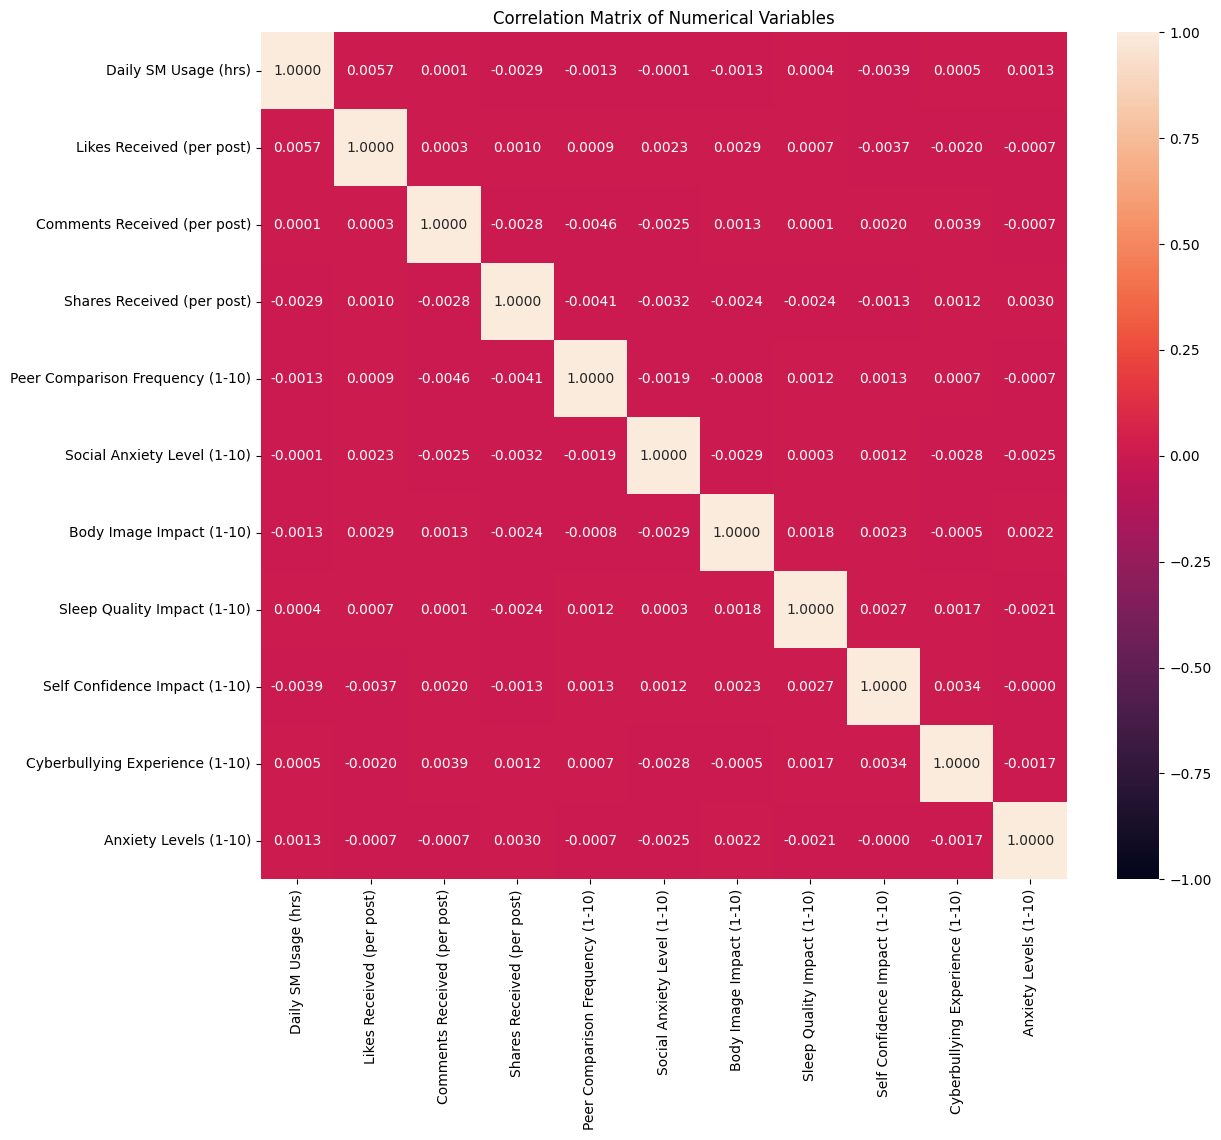

In [ ]:
# Visualization
correlation_matrix = df.select_dtypes(include = ['float64', 'int64']).corr()  # Calculate correlation of all numerical variables
plt.figure(figsize=(13, 11))                                                  # Set the figure size
sns.heatmap(correlation_matrix, vmin = -1, annot = True, fmt = ".4f")         # Create a heatmap
plt.title('Correlation Matrix of Numerical Variables')                        # Set title
plt.show()                                                                    # Show heatmap

Explain:  
This correlation matrix examines the relationships between social media usage patterns and mental health outcomes. The data shows that `Daily SM Usage (hrs)` has a weak correlation with most variables. The strongest positive correlation is with `Likes Received (per post)`, 0.0057 but still minimal. Most mental health outcomes like `Social Anxiety Level (1-10)`, `Body Image Impact (1-10)`, and `Cyberbullying Experience (1-10)` show near-zero correlations with usage metrics. This suggests that the quantity of social media engagement (`Likes Received (per post)`, `Comments Received (per post)`, `Shares Received (per post)`) has little direct linear relationship with mental health outcomes.

## 2.3 Descriptive Statistics

### 2.3.1 Numerical Variables

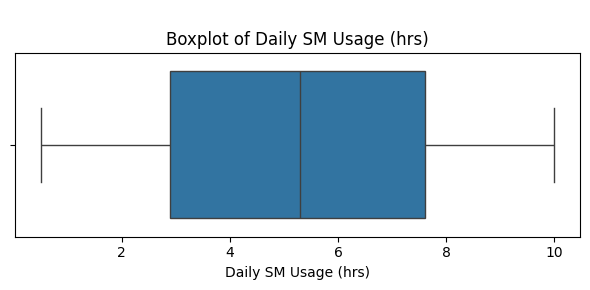

Mode                  8.500
Median                5.300
Mean                  5.270
Variance              7.499
Standard Deviation    2.738
Skewness             -0.009
Kurtosis             -1.198
Name: Daily SM Usage (hrs), dtype: float64
__________________________________________________________________________________________


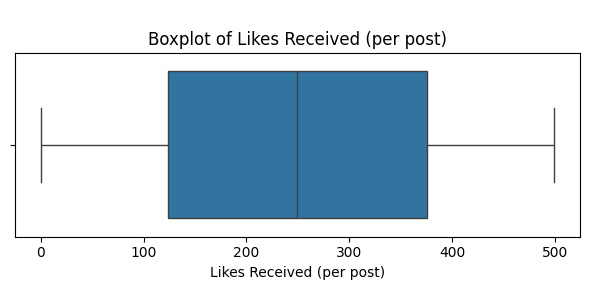

Mode                    318.000
Median                  249.000
Mean                    249.292
Variance              20833.726
Standard Deviation      144.339
Skewness                 -0.000
Kurtosis                 -1.198
Name: Likes Received (per post), dtype: float64
__________________________________________________________________________________________


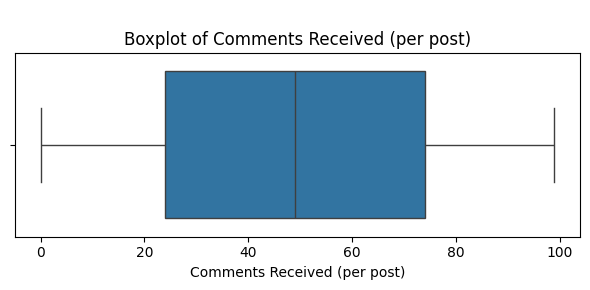

Mode                   88.000
Median                 49.000
Mean                   49.415
Variance              835.113
Standard Deviation     28.898
Skewness                0.004
Kurtosis               -1.204
Name: Comments Received (per post), dtype: float64
__________________________________________________________________________________________


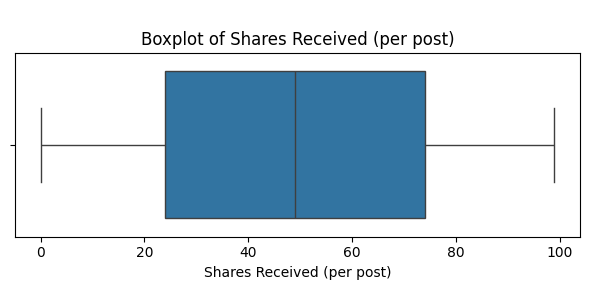

Mode                   42.000
Median                 49.000
Mean                   49.443
Variance              833.475
Standard Deviation     28.870
Skewness                0.003
Kurtosis               -1.199
Name: Shares Received (per post), dtype: float64
__________________________________________________________________________________________


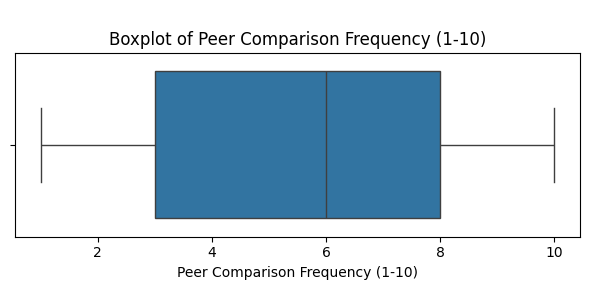

Mode                  9.000
Median                6.000
Mean                  5.508
Variance              8.254
Standard Deviation    2.873
Skewness             -0.004
Kurtosis             -1.226
Name: Peer Comparison Frequency (1-10), dtype: float64
__________________________________________________________________________________________


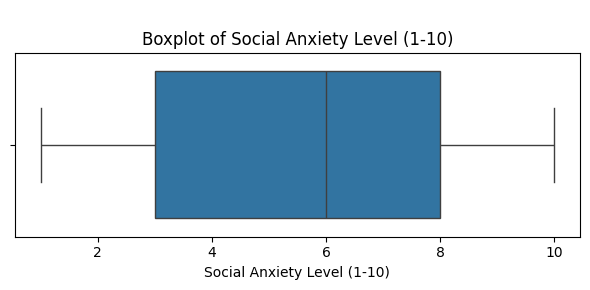

Mode                  1.000
Median                6.000
Mean                  5.494
Variance              8.238
Standard Deviation    2.870
Skewness             -0.002
Kurtosis             -1.221
Name: Social Anxiety Level (1-10), dtype: float64
__________________________________________________________________________________________


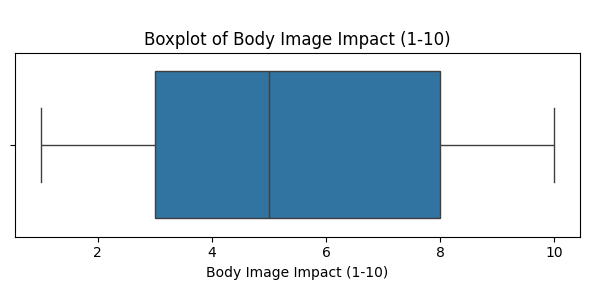

Mode                  3.000
Median                5.000
Mean                  5.500
Variance              8.240
Standard Deviation    2.870
Skewness              0.004
Kurtosis             -1.224
Name: Body Image Impact (1-10), dtype: float64
__________________________________________________________________________________________


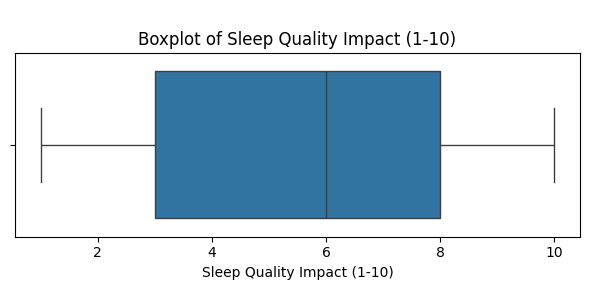

Mode                  7.000
Median                6.000
Mean                  5.513
Variance              8.227
Standard Deviation    2.868
Skewness             -0.007
Kurtosis             -1.221
Name: Sleep Quality Impact (1-10), dtype: float64
__________________________________________________________________________________________


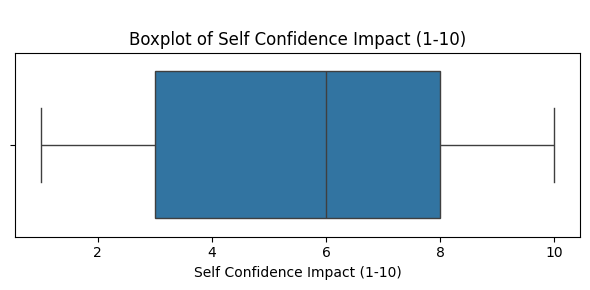

Mode                  10.000
Median                 6.000
Mean                   5.501
Variance               8.269
Standard Deviation     2.876
Skewness              -0.000
Kurtosis              -1.226
Name: Self Confidence Impact (1-10), dtype: float64
__________________________________________________________________________________________


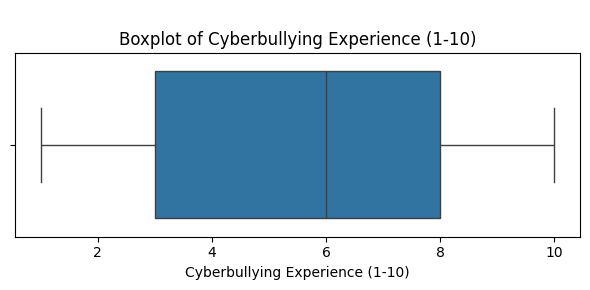

Mode                  9.000
Median                6.000
Mean                  5.501
Variance              8.277
Standard Deviation    2.877
Skewness             -0.001
Kurtosis             -1.228
Name: Cyberbullying Experience (1-10), dtype: float64
__________________________________________________________________________________________


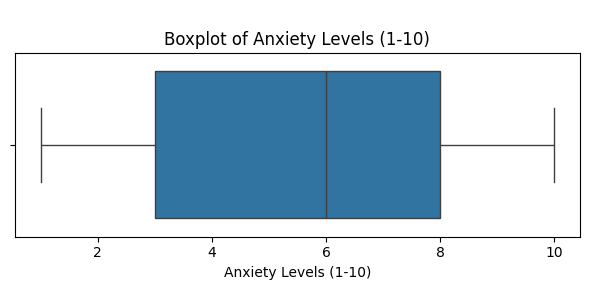

Mode                  8.000
Median                6.000
Mean                  5.501
Variance              8.271
Standard Deviation    2.876
Skewness             -0.002
Kurtosis             -1.226
Name: Anxiety Levels (1-10), dtype: float64
__________________________________________________________________________________________


In [ ]:
# List of specific numerical variables names
selected_variables = ['Daily SM Usage (hrs)', 'Likes Received (per post)', 'Comments Received (per post)', 'Shares Received (per post)',
                      'Peer Comparison Frequency (1-10)', 'Social Anxiety Level (1-10)', 'Body Image Impact (1-10)', 'Sleep Quality Impact (1-10)',
                      'Self Confidence Impact (1-10)', 'Cyberbullying Experience (1-10)', 'Anxiety Levels (1-10)']

# Create a DataFrame with only those selected numerical features
numerical_variables = df[selected_variables]
numerical_variables = numerical_variables.copy() # make a deep copy

# Creating a dictionaries to store data
nv_descrip_stat = {}

# Loop through each numerical variables
for variable in numerical_variables:

    # Perform descriptive statistics
    nv_descrip_stat[variable] = {'Mode': df[variable].value_counts().idxmax(), # Find out the value that occurs most frequently
                                 'Median': df[variable].median(),              # Find out middle value
                                 'Mean': df[variable].mean(),                  # Calculate average
                                 'Variance': df[variable].var(),               # Calculate the spread
                                 'Standard Deviation': df[variable].std(),     # Calculate standard deviation
                                 'Skewness': df[variable].skew(),              # Calculate skewness
                                 'Kurtosis': df[variable].kurtosis()}          # Calculate tailedness of a distribution

# Convert result to DataFrame
numerical_df = pd.DataFrame(nv_descrip_stat)

# Loop through each result
for variable in numerical_df:

    # Visualization
    plt.figure(figsize=(6, 3))                 # Set figure size
    sns.boxplot(data=df[variable], orient='h') # Display horizontal boxplot
    plt.title("\nBoxplot of " + variable)      # Set title
    plt.tight_layout()                         # Avoid overlap
    plt.show()                                 # Show boxplot

    # Display results
    print(numerical_df[variable].round(3))
    print(90*"_")

Explain:  
This descriptive statistics analysis shows that the numerical variables across the dataset are relatively symmetric, with minimal skewness and low kurtosis values.
* `Daily SM Usage (hrs)`
    * Mean and median of around 5.3 hours, suggesting moderate daily use
    * The distribution is approximately symmetric with light tails, skewness=-0.009
* Engagement metrics
    * `Likes Received (per post)`, `Comments Received (per post)`, and `Shares Received (per post)`
    *  All have very close mean and median values, showing balanced user interaction
    *  The standard deviations show moderate variation, with `Likes Received (per post)` having the largest spread
* Mental health outcomes
    * e.g., `Peer Comparison Frequency (1-10)`, `Social Anxiety Level (1-10)`, `Body Image Impact (1-10)`
    * All means range around 5.5 on a scale of 1 to 10, with very low skewness (close to 0)
    * It indicates well-centered and balanced distributions
* All numerical variables have negative kurtosis, also known as platykurtic, which indicates a distribution with a flatter peak and thinner tails compared to a normal distribution

In conclusion, the numerical variables are well-distributed, mostly symmetric, and show no extreme values, providing a stable foundation for further analysis.

### 2.3.2 Categorical Variables

In [ ]:
# List of specific categorical variables names
categorical_variables = ['Country', 'Age Group', 'Gender', 'Urban/Rural', 'Most Used SM Platform', 'Frequency of SM Use',
                         'Socioeconomic Status', 'Education Level', 'State']

# Create a DataFrame with only those selected categorical variables
categorical_variables = df[categorical_variables]
categorical_variables = categorical_variables.copy() # make a deep copy

# Loop through each categorical variable
for variable in categorical_variables:

    # Calculate frequency and percentage
    frequency = df[variable].value_counts()
    percentage = (df[variable].value_counts(normalize=True) * 100).round(2)

    # Create a DataFrame to store the results
    categorical_df = pd.DataFrame({'Frequency': frequency,
                                   'Percentage (%)': percentage})

    # Display results
    print("\n" + variable + " Frequency Distribution\n")
    print(categorical_df)
    print(60*"_")


Country Frequency Distribution

              Frequency  Percentage (%)
Country                                
Uzbekistan        40444           20.22
Kyrgyzstan        40102           20.05
Kazakhstan        40031           20.02
Turkmenistan      39881           19.94
Tajikistan        39542           19.77
____________________________________________________________

Age Group Frequency Distribution

           Frequency  Percentage (%)
Age Group                           
56-65          40164           20.08
26-35          40116           20.06
36-45          40012           20.01
46-55          39907           19.95
18-25          39801           19.90
____________________________________________________________

Gender Frequency Distribution

        Frequency  Percentage (%)
Gender                           
Male       100168           50.08
Female      99832           49.92
____________________________________________________________

Urban/Rural Frequency Distribution

     

Explain:
This descriptive analysis of categorical variables indicates a well-balanced and representative dataset across demographic, geographic, and behavioral dimensions:  
* `Country`
    * Participants are almost evenly distributed across Uzbekistan, Kyrgyzstan, Kazakhstan, Turkmenistan, and Tajikistan.
    * Each country contributes around 20% to the dataset.
* `Age Group`
    * The distribution is similarly balanced, with all five groups (18–25 through 56–65) nearly equally represented, around 20% for each age group.
* `Gender`
    * The population is nearly evenly split between males and females, around 50% for each gender.
* `Urban/Rural`
    * The population is nearly evenly split between urban and rural, around 50% for each.
* `Most Used SM Platforms`
    * TikTok, Twitter, Facebook, Snapchat, and Instagram are all equally used, with usage frequencies ranging from 19.9% to 20.1%.
* `Frequency of SM Use`
    * Weekly, monthly, and daily users are evenly spread, around 33% for each, enabling comparison across usage frequency.
* `Socioeconomic Status`
    * Low, middle, and high socioeconomic status groups are almost equally represented, around 33% for each, allowing robust cross-status analysis.
* `Education Level`
    * The sample includes a range of education levels: PhD, high school, bachelor's, and master's.
    * The PhD holders form the largest group, 25.13%, followed closely by high school: 24.96%, bachelor's: 24.96%, and master's: 24.94% holders.
* `State`
    * The data is geographically well-distributed across 20 states, each contributing around 5% of the total, supporting region-based comparisons.

This balanced distribution across categories ensures a reliable foundation for demographic and behavioral analysis.

## 2.4 Feature Enginnering: Feature Creation

### 2.4.1 Numerical Variables

In [ ]:
# Select all mental health variables
mental_health_variables = ['Social Anxiety Level (1-10)', 'Body Image Impact (1-10)', 'Sleep Quality Impact (1-10)',
                           'Self Confidence Impact (1-10)', 'Anxiety Levels (1-10)']

# Create new variable with mean of total mental health score
numerical_variables['mental_health_score'] = numerical_variables[mental_health_variables].mean(axis=1)
numerical_variables.head()

,Daily SM Usage (hrs),Likes Received (per post),Comments Received (per post),Shares Received (per post),Peer Comparison Frequency (1-10),Social Anxiety Level (1-10),Body Image Impact (1-10),Sleep Quality Impact (1-10),Self Confidence Impact (1-10),Cyberbullying Experience (1-10),Anxiety Levels (1-10),mental_health_score
0,6.3,302,56,32,1,6,8,9,5,2,7,7.0
1,1.2,294,80,25,1,6,5,1,9,5,3,4.8
2,4.8,288,20,8,6,3,9,9,4,5,8,6.6
3,1.4,169,1,86,2,7,5,5,6,7,3,5.2
4,0.8,371,31,6,5,3,10,7,6,1,10,7.2


Explain:
This code generates a new variable called `mental_health_score`, which is determined by taking the average of five variables related to mental health: `anxiety levels (1–10)`,` body image impact (1–10)`, `sleep quality impact (1–10)`, `self-confidence impact (1–10)`, and `social anxiety level (1–10)`. The `numerical_variables` DataFrame is then updated with the new variable. The successful creation and appending of the new column is confirmed by the `.head()` output.

### 2.4.2 Categorical Variables

In [ ]:
# Function to identify mental health level
def mental_health_level(mh_score):
  if mh_score >= 7.5:
    return 'Severe'
  elif mh_score >= 5:
    return 'Moderate'
  elif mh_score >= 2.5:
    return 'Mild'
  else:
    return 'Low'

# Create a new column 'mental_health_level' based on 'mental_health_score'
categorical_variables['mental_health_level'] = numerical_variables['mental_health_score'].apply(mental_health_level)
categorical_variables.head()

,Country,Age Group,Gender,Urban/Rural,Most Used SM Platform,Frequency of SM Use,Socioeconomic Status,Education Level,State,mental_health_level
0,Uzbekistan,18-25,Female,Rural,Instagram,Weekly,Middle,Master's,Bukhara,Moderate
1,Uzbekistan,18-25,Male,Rural,Facebook,Weekly,High,Bachelor's,Namangan,Mild
2,Uzbekistan,36-45,Male,Rural,Instagram,Monthly,Low,High School,Samarkand,Moderate
3,Turkmenistan,36-45,Female,Rural,Twitter,Daily,High,Bachelor's,Dashoguz,Moderate
4,Kazakhstan,56-65,Female,Rural,Twitter,Weekly,High,Master's,Karaganda,Moderate


Explain:  
This code includes a function called `mental_health_level()` that helps categorize people based on their mental health scores. The different categories generated by this function are then saved in a new column called `mental_health_level` within the `categorical_variables` DataFrame. To check that everything worked correctly, the output of the `.head()` function shows that the new column has been successfully added.

## 2.5 Numerical Features Analysis

### 2.5.1 Outlier Detection and Handling

**Identify Outliers**

In [ ]:
# Function to identify outliers
def identify_outliers(df, v):
    Q1 = df[v].quantile(0.25)
    Q3 = df[v].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)
    outliers = df[(df[v] < lower_limit) | (df[v] > upper_limit)]
    return outliers, lower_limit, upper_limit

# Create an empty list to store the result
nf_outlier_summary = []

# Identify the outlier details for numerical variables
for variable in numerical_variables:
    outliers, lower, upper = identify_outliers(numerical_variables, variable)
    nf_outlier_summary.append({'Variable': variable,
                              'Num_outliers': len(outliers),
                              'Lower_limit': lower,
                              'Upper_limit': upper,
                              'Min_value': numerical_variables[variable].min(),
                              'Max_value': numerical_variables[variable].max(),
                              'Decision': 'Remain' if len(outliers) == 0 else 'Handle' })

# Convert to a DataFrame for nice display
nf_outlier_summary = pd.DataFrame(nf_outlier_summary)

# Display the outlier summary
nf_outlier_summary

,Variable,Num_outliers,Lower_limit,Upper_limit,Min_value,Max_value,Decision
0,Daily SM Usage (hrs),0,-4.15,14.65,0.5,10.0,Remain
1,Likes Received (per post),0,-252.50,751.50,0.0,499.0,Remain
2,Comments Received (per post),0,-51.00,149.00,0.0,99.0,Remain
3,Shares Received (per post),0,-51.00,149.00,0.0,99.0,Remain
4,Peer Comparison Frequency (1-10),0,-4.50,15.50,1.0,10.0,Remain
5,Social Anxiety Level (1-10),0,-4.50,15.50,1.0,10.0,Remain
6,Body Image Impact (1-10),0,-4.50,15.50,1.0,10.0,Remain
7,Sleep Quality Impact (1-10),0,-4.50,15.50,1.0,10.0,Remain
8,Self Confidence Impact (1-10),0,-4.50,15.50,1.0,10.0,Remain
9,Cyberbullying Experience (1-10),0,-4.50,15.50,1.0,10.0,Remain


**Visualize Outliers**

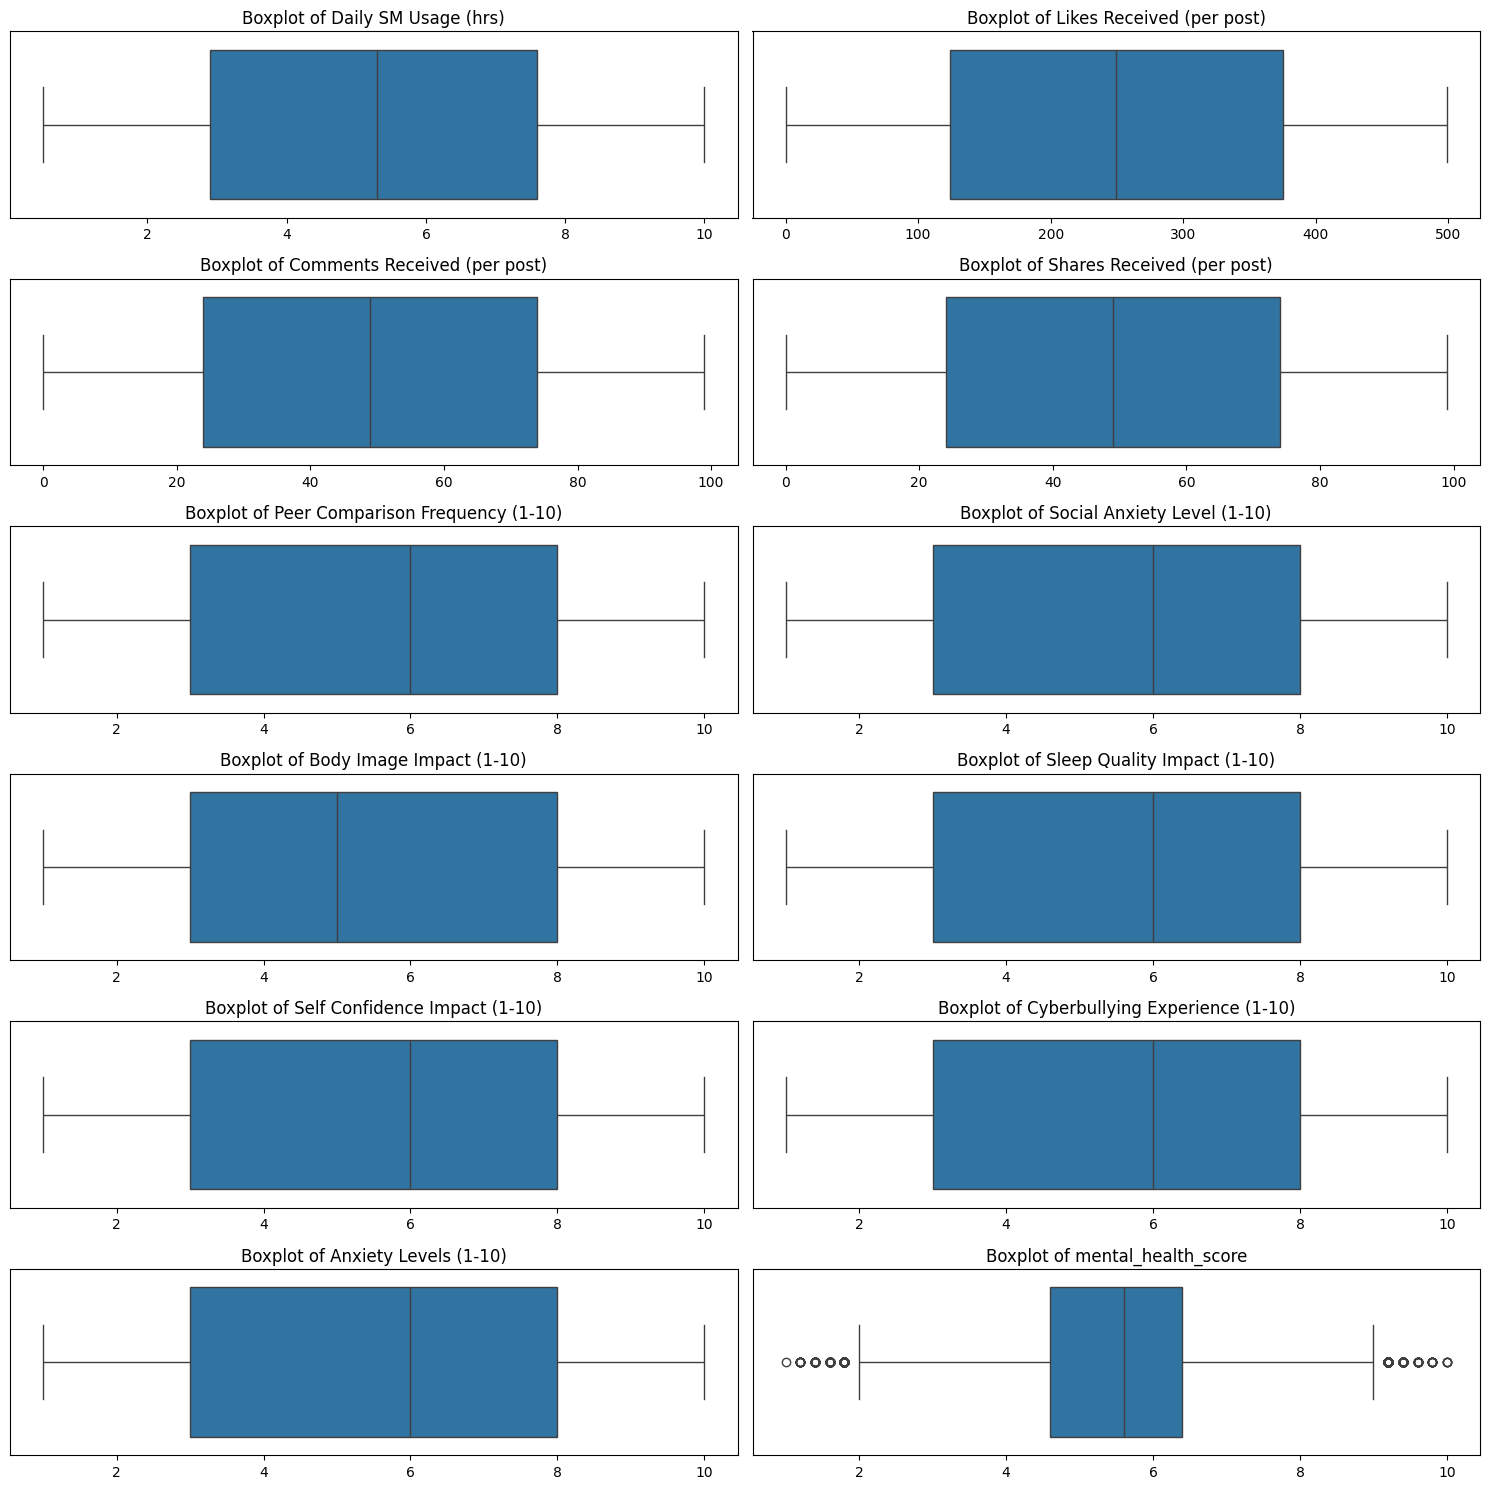

In [ ]:
# Visualization of outliers
# Create subplots: 6 rows x 2 columns (12 slots)
fig, axes = plt.subplots(figsize=(15, 15), nrows=6, ncols=2)

# Convert NumPy array into a one-dimensional array
axes = axes.flatten()

# Loop through numerical_variables and plot boxplot
for i, variable in enumerate(numerical_variables): # enumerate: get index and variable name
    sns.boxplot(data=numerical_variables, x=variable, ax=axes[i])   # Plot a boxplot
    axes[i].set_title("Boxplot of " + variable)    # Set boxplot title
    axes[i].set_xlabel('')                         # Remove x-axis label
    axes[i].set(yticks=[])                         # Remove yticks

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Explain:  
Based on the analysis and boxplot visualizations, no outliers were detected in any of the numerical variables except `mental_health_score`. The IQR method was used to define lower and upper bounds, and almost all observed minimum and maximum values fall within these ranges. A total of 486 outliers were found for `mental_health_score`, but `mental_health_score` is one of the target variables, so no outlier handling is required to avoid affecting the pattern and reality of the analysis results. As a result, no data points were removed or modified, and all original values were retained for analysis.

**Identify Skewness**

In [ ]:
# Create a list of dictionaries to store variables and skewness
nf_skewness_summary = []

# Copy the list of numerical variables
variables = [col for col in numerical_variables]

# Measure skewness for each variables
for variable in variables:
    skew_val = numerical_variables[variable].skew()
    nf_skewness_summary.append({'Variable': variable,
                                'Skewness': skew_val,
                                'Transformation': 'Need' if skew_val > 1 or skew_val < -1 else 'No need'})

# Convert to DataFrame
nf_skewness_summary = pd.DataFrame(nf_skewness_summary)
nf_skewness_summary.round(3)

,Variable,Skewness,Transformation
0,Daily SM Usage (hrs),-0.009,No need
1,Likes Received (per post),-0.000,No need
2,Comments Received (per post),0.004,No need
3,Shares Received (per post),0.003,No need
4,Peer Comparison Frequency (1-10),-0.004,No need
5,Social Anxiety Level (1-10),-0.002,No need
6,Body Image Impact (1-10),0.004,No need
7,Sleep Quality Impact (1-10),-0.007,No need
8,Self Confidence Impact (1-10),-0.000,No need
9,Cyberbullying Experience (1-10),-0.001,No need


Explain:  
This code measures the skewness of each numerical variable by using the `.skew()` function to identify whether any data transformation is needed. The results indicate that all the variables have skewness values ranging from -1 to 1. The results show that all variable distributions are fairly symmetrical, meaning there is no need to perform transformations. This includes the mental_health_score variable, reinforcing our earlier conclusion that no transformation is required.

### 2.5.2 Standardized Data

In [ ]:
# Make a copy of the numerical variables to apply standardization
stand_numerical_variables = numerical_variables.copy()
stand_numerical_variables.head()

# Standardize each numerical variable except target variable: mental_health_score
for variable in stand_numerical_variables:
  # Skip standardization for the target variable
  if variable == 'mental_health_score':
    continue
  # Perform standard scaling to each variable
  stand_numerical_variables[variable] = StandardScaler().fit_transform(stand_numerical_variables[[variable]])

# Display the results
stand_numerical_variables.head()

,Daily SM Usage (hrs),Likes Received (per post),Comments Received (per post),Shares Received (per post),Peer Comparison Frequency (1-10),Social Anxiety Level (1-10),Body Image Impact (1-10),Sleep Quality Impact (1-10),Self Confidence Impact (1-10),Cyberbullying Experience (1-10),Anxiety Levels (1-10),mental_health_score
0,0.376303,0.365166,0.227866,-0.604198,-1.568961,0.176201,0.870909,1.215779,-0.174190,-1.217003,0.521367,7.0
1,-1.486112,0.309741,1.058366,-0.846665,-1.568961,0.176201,-0.174211,-1.573305,1.216870,-0.174214,-0.869516,4.8
2,-0.171466,0.268172,-1.017884,-1.435514,0.171384,-0.869056,1.219282,1.215779,-0.521955,-0.174214,0.869088,6.6
3,-1.413076,-0.556279,-1.675363,1.266262,-1.220892,0.524620,-0.174211,-0.178763,0.173575,0.520979,-0.869516,5.2
4,-1.632183,0.843208,-0.637238,-1.504790,-0.176685,-0.869056,1.567655,0.518508,0.173575,-1.564600,1.564530,7.2


Explain:  
This code applies standardized using `StandardScaler()`, which transforms each feature to a mean of 0 and a standard deviation of 1. This step is to ensure all variables have the same scale. The target variable: `mental_health_score` was excluded from standardizes to retain its original values.

### 2.5.3 Correlation Analysis

In [ ]:
# Select target variables and non-mental health variables
selected_variables = stand_numerical_variables[['Daily SM Usage (hrs)', 'Likes Received (per post)', 'Comments Received (per post)', 'Shares Received (per post)', 'Peer Comparison Frequency (1-10)',
                                                'Social Anxiety Level (1-10)', 'Sleep Quality Impact (1-10)', 'Cyberbullying Experience (1-10)', 'Anxiety Levels (1-10)', 'mental_health_score']].copy()

**Correlation of Numerical Features with Target 1: `mental_health_score`**

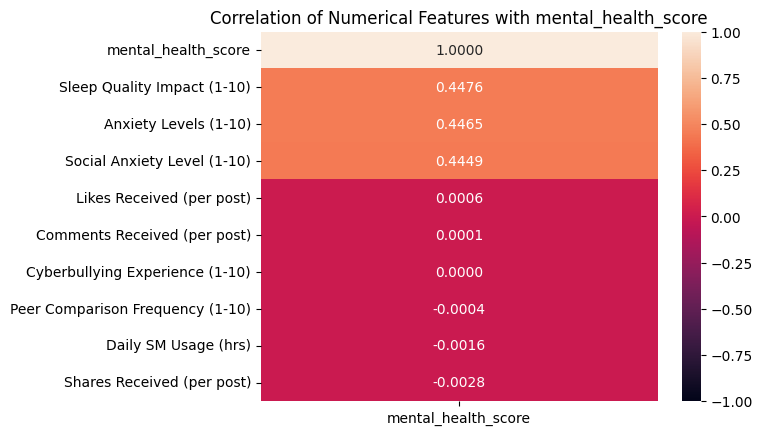

In [ ]:
# Calculates a correlation matrix with 'mental_health_score' and sorts
correlation_matrix = selected_variables.corr()[['mental_health_score']].sort_values('mental_health_score', ascending=False)

# Plot the heatmap
sns.heatmap(correlation_matrix, vmin = -1, annot = True, fmt = ".4f")
plt.title('Correlation of Numerical Features with mental_health_score')
plt.show()                                                                   # Show heatmap

Explain:  
This code calculates the correlation of selected variables with the target variable: `mental_health_score`, and visualizes with a heatmap. By ignoring other target variables (`Sleep Quality Impact (1-10)`, `Anxiety Levels (1-10)`, and `Social Anxiety Level (1-10)`) in the heatmap, `Shares Received (per post)` have a higher correlation with `mental_health_score` but is a negative correlation. The `Cyberbullying Experience (1-10)` shows zero correlation with the target variable.

**Correlation of Numerical Features with Target 2: `Anxiety Levels (1-10)`**

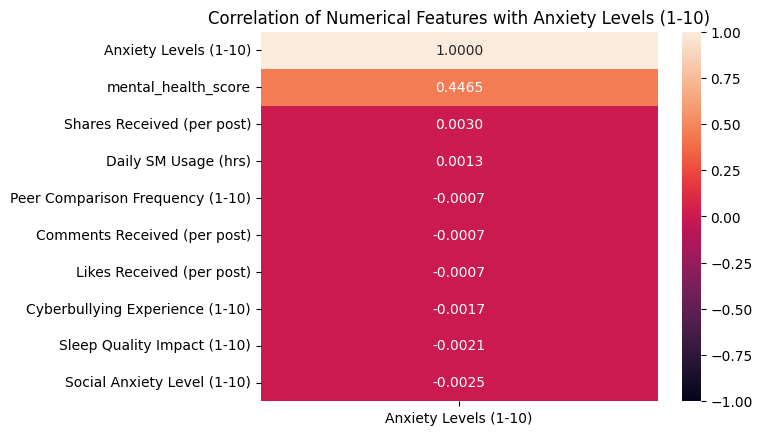

In [ ]:
# Calculates a correlation matrix with 'Anxiety Levels (1-10)' and sorts
correlation_matrix = selected_variables.corr()[['Anxiety Levels (1-10)']].sort_values('Anxiety Levels (1-10)', ascending=False)

# Plot the heatmap
sns.heatmap(correlation_matrix, vmin = -1, annot = True, fmt = ".4f")
plt.title('Correlation of Numerical Features with Anxiety Levels (1-10)')
plt.show()

Explain:  
This code calculates the correlation of selected variables with the target variable: `Anxiety Levels (1-10)`, and visualizes with a heatmap. By ignoring other target variables (`Sleep Quality Impact (1-10)`, `mental_health_score`, and `Social Anxiety Level (1-10)`) in the heatmap, `Shares Received (per post)` have a higher correlation with `mental_health_score` but opposite with previous one, is a positive correlation. The `Cyberbullying Experience (1-10)` has the highest negative correlation with the target variable, -0.0017.

**Correlation of Numerical Features with Target 3: `Social Anxiety Level (1-10)
`**

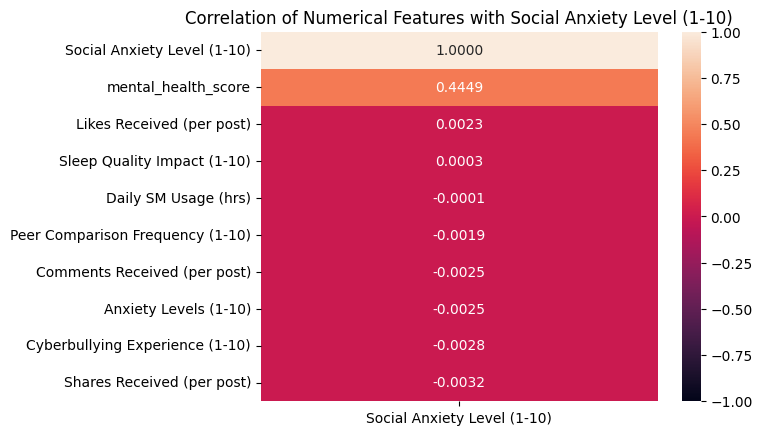

In [ ]:
# Calculates a correlation matrix with 'Social Anxiety Level (1-10)' and sorts
correlation_matrix = selected_variables.corr()[['Social Anxiety Level (1-10)']].sort_values('Social Anxiety Level (1-10)', ascending=False)

# Plot the heatmap
sns.heatmap(correlation_matrix, vmin = -1, annot = True, fmt = ".4f")
plt.title('Correlation of Numerical Features with Social Anxiety Level (1-10)')
plt.show()

Explain:  
This code calculates the correlation of selected variables with the target variable: `Social Anxiety Level (1-10)`, and visualizes with a heatmap. By ignoring other target variables (`Sleep Quality Impact (1-10)`, `mental_health_score`, and `Anxiety Levels (1-10)`) in the heatmap, `Likes Received (per post)` have a higher correlation with target, 0.0023. The `Shares Received (per post)` has the highest negative correlation with the target variable,  -0.0032.

**Correlation of Numerical Features with Target 4: `Sleep Quality Impact (1-10)`**

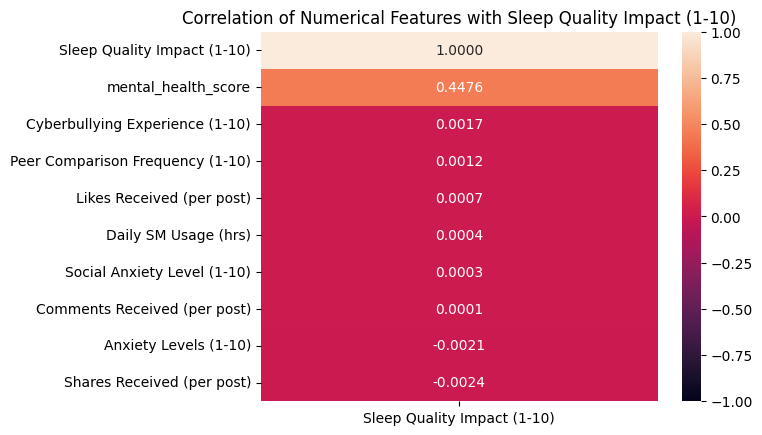

In [ ]:
# Calculates a correlation matrix with 'Sleep Quality Impact (1-10)' and sorts
correlation_matrix = selected_variables.corr()[['Sleep Quality Impact (1-10)']].sort_values('Sleep Quality Impact (1-10)', ascending=False)

# Plot the heatmap
sns.heatmap(correlation_matrix, vmin = -1, annot = True, fmt = ".4f")
plt.title('Correlation of Numerical Features with Sleep Quality Impact (1-10)')
plt.show()

Explain:  
This code calculates the correlation of selected variables with the target variable: `Sleep Quality Impact (1-10)`, and visualizes with a heatmap. By ignoring other target variables (`Anxiety Levels (1-10)`, `mental_health_score`, and `Social Anxiety Level (1-10)`) in the heatmap, `Cyberbullying Experience (1-10)` have a higher correlation with target, 0.0017. The `Shared Received (per post)` has the highest negative correlation with the target variable, -0.0024.  

### 2.5.4 Calculate Mutual Information

The purpose of calculating mutual information is to measure the strength and dependency between each selected variable and the target variable. The
`mutual_info_regression` and `mutual_info_classif` are used to calculate mutual information. For numerical target variables, `mutual_info_regression` is applied to identify which selected variables contribute the most to predicting variations in the target. On the other hand, `mutual_info_classif` is used when the target variable is categorical. Mutual information is helpful for feature selection because it identifies variables with high predictive relevance to the outcome, different from correlation, which only captures linear relationships.

In [ ]:
# Select necessary variables
variables = stand_numerical_variables[['Daily SM Usage (hrs)', 'Likes Received (per post)', 'Comments Received (per post)', 'Shares Received (per post)', 'Peer Comparison Frequency (1-10)',
                                       'Cyberbullying Experience (1-10)']].copy()

**Target 1: `mental_health_score`**

In [ ]:
# Initialize an empty list to store mutual information scores
mhs_mi = []

# Loop through each selected variable
for variable in variables:
  # Calculate mutual information scores
  scores = mutual_info_regression(variables[[variable]], stand_numerical_variables['mental_health_score'], random_state=0)
  # Append the variable name and its mutual information score to the list
  mhs_mi.append({'variables': variable,
                 'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
mhs_mi_df = pd.DataFrame(mhs_mi)
mhs_mi_df = mhs_mi_df.sort_values(by='mi_scores', ascending=False)
mhs_mi_df = mhs_mi_df.reset_index(drop=True)

# Display results
mhs_mi_df

,variables,mi_scores
0,Likes Received (per post),0.004341
1,Comments Received (per post),0.001955
2,Cyberbullying Experience (1-10),0.001195
3,Peer Comparison Frequency (1-10),0.000924
4,Daily SM Usage (hrs),0.000747
5,Shares Received (per post),0.000000


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_regression`. The results show that `Likes Received (per post)` has the highest mutual information score. This indicates that `Likes Received (per post)` is the most relevant variable for predicting the target variable, `mental_health_score`.

**Target 2: `mental_health_level`**

In [ ]:
# Initialize an empty list to store mutual information scores
mhl_mi = []

# Loop through each selected variable
for variable in variables:
  # Calculate mutual information scores
  scores = mutual_info_classif(variables[[variable]], categorical_variables['mental_health_level'], random_state=0)
  # Append the variable name and its mutual information score to the list
  mhl_mi.append({'variables': variable,
                 'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
mhl_mi_df = pd.DataFrame(mhl_mi)
mhl_mi_df = mhl_mi_df.sort_values(by='mi_scores', ascending=False)
mhl_mi_df = mhl_mi_df.reset_index(drop=True)

# Display results
mhl_mi_df

,variables,mi_scores
0,Cyberbullying Experience (1-10),0.004350
1,Shares Received (per post),0.002497
2,Peer Comparison Frequency (1-10),0.001549
3,Comments Received (per post),0.000254
4,Likes Received (per post),0.000000
5,Daily SM Usage (hrs),0.000000


Explain:  
This code calculates mutual information between the selected variable and the categorical target with `mutual_info_classif`. The results show that `Cyberbullying Experience (1-10)` has the highest mutual information score, 0.004350. This indicates that `Cyberbullying Experience (1-10)` is the most relevant variable for predicting the target variable, `mental_health_level`.

**Target 3: `Anxiety Levels (1-10)`**

In [ ]:
# Initialize an empty list to store mutual information scores
al_mi = []

# Loop through each selected variable
for variable in variables:
  # Calculate mutual information scores
  scores = mutual_info_regression(variables[[variable]], stand_numerical_variables['Anxiety Levels (1-10)'], random_state=0)
  # Append the variable name and its mutual information score to the list
  al_mi.append({'variables': variable,
                'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
al_mi_df = pd.DataFrame(al_mi)
al_mi_df = al_mi_df.sort_values(by='mi_scores', ascending=False)
al_mi_df = al_mi_df.reset_index(drop=True)

# Display results
al_mi_df

,variables,mi_scores
0,Comments Received (per post),0.001377
1,Cyberbullying Experience (1-10),0.001352
2,Daily SM Usage (hrs),0.001143
3,Likes Received (per post),0.000027
4,Shares Received (per post),0.000000
5,Peer Comparison Frequency (1-10),0.000000


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_regression`. The results show that `Comments Received (per post)` has the highest mutual information score, 0.001377. This indicates that `Comments Received (per post)` is the most relevant variable for predicting the target variable, `Anxiety Levels (1-10)`.

**Target 4: `Social Anxiety Level (1-10)`**

In [ ]:
# Initialize an empty list to store mutual information scores
sal_mi = []

# Loop through each selected variable
for variable in variables:
  # Calculate mutual information scores
  scores = mutual_info_regression(variables[[variable]], stand_numerical_variables['mental_health_score'], random_state=0)
  # Append the variable name and its mutual information score to the list
  sal_mi.append({'variables': variable,
                 'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
sal_mi_df = pd.DataFrame(sal_mi)
sal_mi_df = sal_mi_df.sort_values(by='mi_scores', ascending=False)
sal_mi_df = sal_mi_df.reset_index(drop=True)

# Display results
sal_mi_df

,variables,mi_scores
0,Likes Received (per post),0.004341
1,Comments Received (per post),0.001955
2,Cyberbullying Experience (1-10),0.001195
3,Peer Comparison Frequency (1-10),0.000924
4,Daily SM Usage (hrs),0.000747
5,Shares Received (per post),0.000000


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_regression`. The results show that `Likes Received (per post)` has the highest mutual information score, 0.004341. This indicates that `Likes Received (per post)` is the most relevant variable for predicting the target variable, `Social Anxiety Level (1-10)`.

**Target 5: `Sleep Quality Impact (1-10)`**

In [ ]:
# Initialize an empty list to store mutual information scores
sqi_mi = []

# Loop through each selected variable
for variable in variables:
  # Calculate mutual information scores
  scores = mutual_info_regression(variables[[variable]], stand_numerical_variables['mental_health_score'], random_state=0)
  # Append the variable name and its mutual information score to the list
  sqi_mi.append({'variables': variable,
                 'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
sqi_mi_df = pd.DataFrame(sqi_mi)
sqi_mi_df = sqi_mi_df.sort_values(by='mi_scores', ascending=False)
sqi_mi_df = sqi_mi_df.reset_index(drop=True)

# Display results
sqi_mi_df

,variables,mi_scores
0,Likes Received (per post),0.004341
1,Comments Received (per post),0.001955
2,Cyberbullying Experience (1-10),0.001195
3,Peer Comparison Frequency (1-10),0.000924
4,Daily SM Usage (hrs),0.000747
5,Shares Received (per post),0.000000


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_regression`. The results show that `Likes Received (per post)` has the highest mutual information score, 0.004341. This indicates that `Likes Received (per post)` is the most relevant variable for predicting the target variable, `Sleep Quality Impact (1-10)`.

## 2.6 Categorical Features Analysis

### 2.6.1 Outlier Detection and Handling

In [ ]:
for variable in categorical_variables.columns:
    print(variable)
    counts = categorical_variables[variable].value_counts()
    outlier = 0
    for name, count in counts.items():
        print(name + ": " + str(count))
        if count < len(df)*0.005:
            outlier = outlier + 1
    print("Total outliers: " + str(outlier))
    print("")

Country
Uzbekistan: 40444
Kyrgyzstan: 40102
Kazakhstan: 40031
Turkmenistan: 39881
Tajikistan: 39542
Total outliers: 0

Age Group
56-65: 40164
26-35: 40116
36-45: 40012
46-55: 39907
18-25: 39801
Total outliers: 0

Gender
Male: 100168
Female: 99832
Total outliers: 0

Urban/Rural
Urban: 100180
Rural: 99820
Total outliers: 0

Most Used SM Platform
TikTok: 40208
Twitter: 40103
Facebook: 39912
Snapchat: 39906
Instagram: 39871
Total outliers: 0

Frequency of SM Use
Weekly: 66830
Monthly: 66765
Daily: 66405
Total outliers: 0

Socioeconomic Status
Low: 66842
Middle: 66657
High: 66501
Total outliers: 0

Education Level
PhD: 50267
High School: 49929
Bachelor's: 49921
Master's: 49883
Total outliers: 0

State
Tashkent: 10160
Samarkand: 10097
Dashoguz: 10096
Namangan: 10095
Bukhara: 10092
Karakol: 10069
Shymkent: 10051
Osh: 10048
Khujand: 10041
Karaganda: 10036
Jalal-Abad: 10009
Almaty: 10005
Bishkek: 9976
Mary: 9941
Ashgabat: 9940
Nur-Sultan: 9939
Turkmenabat: 9904
Kulob: 9887
Dushanbe: 9825
Bokhta

Explain:  

The code identifies potential outliers in categorical variables based on group frequency. Specifically, any category with a frequency less than 0.5% of the total dataset size is considered an outlier. The results indicate that none of the categorical variables contain such low-frequency categories. Therefore, no outliers were detected among the categorical variables.

### 2.6.2 Calculate Mutual Information

The purpose of calculating mutual information is to measure the strength and dependency between each selected variable and the target variable. The
`mutual_info_regression` and `mutual_info_classif` are used to calculate mutual information. For numerical target variables, `mutual_info_regression` is applied to identify which selected variables contribute the most to predicting variations in the target. On the other hand, `mutual_info_classif` is used when the target variable is categorical. Mutual information is helpful for feature selection because it identifies variables with high predictive relevance to the outcome, different from correlation, which only captures linear relationships.

In [ ]:
# Select necessary variables
encode_variables = categorical_variables.copy()
encode_variables.drop(columns=['mental_health_level'], axis=1, inplace=True)

# Encode selected variables
for variable in encode_variables:
  encode_variables[variable] = LabelEncoder().fit_transform(encode_variables[variable])

**Target 1:`mental_health_score`**

In [ ]:
# Initialize an empty list to store mutual information scores
mhs_cmi = []

#  Loop through each selected variable
for variable in encode_variables:
  # Calculate mutual information scores
  scores = mutual_info_regression(encode_variables[[variable]], stand_numerical_variables['mental_health_score'], random_state=0)
  # Append the variable name and its mutual information score to the list
  mhs_cmi.append({'variables': variable,
                  'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
mhs_cmi_df = pd.DataFrame(mhs_cmi)
mhs_cmi_df = mhs_cmi_df.sort_values(by='mi_scores', ascending=False)
mhs_cmi_df = mhs_cmi_df.reset_index(drop=True)

# Display results
mhs_cmi_df

,variables,mi_scores
0,Country,0.002855
1,Most Used SM Platform,0.002208
2,State,0.002016
3,Age Group,0.001693
4,Socioeconomic Status,0.000383
5,Urban/Rural,0.000000
6,Gender,0.000000
7,Frequency of SM Use,0.000000
8,Education Level,0.000000


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_regression`. The results show that `Country` has the highest mutual information score, 0.002855. This indicates that `Country` is the most relevant variable for predicting the target variable, `mental_health_score`.

**Target 2: `mental_health_level`**

In [ ]:
# Initialize an empty list to store mutual information scores
mhl_cmi = []

#  Loop through each selected variable
for variable in encode_variables:
  # Perform encode toward target variable
  target = LabelEncoder().fit_transform(categorical_variables['mental_health_level'])
  # Calculate mutual information scores
  scores = mutual_info_classif(encode_variables[[variable]], target, random_state=0)
  # Append the variable name and its mutual information score to the list
  mhl_cmi.append({'variables': variable,
                  'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
mhl_cmi_df = pd.DataFrame(mhl_cmi)
mhl_cmi_df = mhl_cmi_df.sort_values(by='mi_scores', ascending=False)
mhl_cmi_df = mhl_cmi_df.reset_index(drop=True)

# Display results
mhl_cmi_df

,variables,mi_scores
0,Urban/Rural,0.015794
1,Gender,0.013275
2,Socioeconomic Status,0.006919
3,Frequency of SM Use,0.006709
4,Education Level,0.005241
5,Most Used SM Platform,0.004895
6,Country,0.004223
7,Age Group,0.001844
8,State,0.001166


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_classif`. The results show that `Urban/Rural` has the highest mutual information score, 0.015794. This indicates that `Urban/Rural` is the most relevant variable for predicting the target variable, `mental_health_level`.

**Target 3: `Anxiety Levels (1-10)`**

In [ ]:
# Initialize an empty list to store mutual information scores
al_cmi = []

# Loop through each selected variable
for variable in encode_variables:
  # Calculate mutual information scores
  scores = mutual_info_regression(encode_variables[[variable]], stand_numerical_variables['Anxiety Levels (1-10)'], random_state=0)
  # Append the variable name and its mutual information score to the list
  al_cmi.append({'variables': variable,
                 'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
al_cmi_df = pd.DataFrame(al_cmi)
al_cmi_df = al_cmi_df.sort_values(by='mi_scores', ascending=False)
al_cmi_df = al_cmi_df.reset_index(drop=True)

# Display results
al_cmi_df

,variables,mi_scores
0,Age Group,0.002024
1,Country,0.001371
2,State,0.001190
3,Gender,0.000760
4,Education Level,0.000352
5,Most Used SM Platform,0.000000
6,Urban/Rural,0.000000
7,Socioeconomic Status,0.000000
8,Frequency of SM Use,0.000000


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_regression`. The results show that `Age Group` has the highest mutual information score, 0.002024. This indicates that `Age Group` is the most relevant variable for predicting the target variable, `Anxiety Levels (1-10)`.

**Target 4: `Social Anxiety Level (1-10)`**

In [ ]:
# Initialize an empty list to store mutual information scores
sal_cmi = []

# Loop through each selected variable
for variable in encode_variables:
  # Calculate mutual information scores
  scores = mutual_info_regression(encode_variables[[variable]], stand_numerical_variables['Social Anxiety Level (1-10)'], random_state=0)
  # Append the variable name and its mutual information score to the list
  sal_cmi.append({'variables': variable,
                  'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
sal_cmi_df = pd.DataFrame(sal_cmi)
sal_cmi_df = sal_cmi_df.sort_values(by='mi_scores', ascending=False)
sal_cmi_df = sal_cmi_df.reset_index(drop=True)

# Display results
sal_cmi_df

,variables,mi_scores
0,Gender,0.003141
1,Frequency of SM Use,0.002912
2,Socioeconomic Status,0.002666
3,Age Group,0.001086
4,Urban/Rural,0.000621
5,Country,0.000000
6,Most Used SM Platform,0.000000
7,Education Level,0.000000
8,State,0.000000


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_regression`. The results show that `Gender` has the highest mutual information score, 0.003141. This indicates that `Gender` is the most relevant variable for predicting the target variable, `Social Anxiety Level (1-10)`.

**Target 5: `Sleep Quality Impact (1-10)`**

In [ ]:
# Initialize an empty list to store mutual information scores
sqi_cmi = []

# Loop through each selected variable
for variable in encode_variables:
  # Calculate mutual information scores
  scores = mutual_info_regression(encode_variables[[variable]], stand_numerical_variables['Sleep Quality Impact (1-10)'], random_state=0)
  # Append the variable name and its mutual information score to the list
  sqi_cmi.append({'variables': variable,
                  'mi_scores': scores[0]})

# Convert the results list into a DataFrame and sort in descending order
sqi_cmi_df = pd.DataFrame(sqi_cmi)
sqi_cmi_df = sqi_cmi_df.sort_values(by='mi_scores', ascending=False)
sqi_cmi_df = sqi_cmi_df.reset_index(drop=True)

# Display results
sqi_cmi_df

,variables,mi_scores
0,State,0.003400
1,Most Used SM Platform,0.001459
2,Frequency of SM Use,0.000956
3,Country,0.000453
4,Gender,0.000444
5,Socioeconomic Status,0.000428
6,Age Group,0.000242
7,Urban/Rural,0.000000
8,Education Level,0.000000


Explain:  
This code calculates mutual information between the selected variable and the numerical target with `mutual_info_regression`. The results show that `State` has the highest mutual information score, 0.003400. This indicates that `State` is the most relevant variable for predicting the target variable, `Sleep Quality Impact (1-10)`.

## 2.7 Feature Engineering: Feature Selection

### 2.7.1 Mutual Information

Mutual Information (MI) is a non-parametric measure that captures the dependent relationship between variables no matter what variable type or distribution. Mutual Information is different from linear correlation. Mutual Information can detect linear and non-linear relationships, and identify variables that share information with the target, even in complex or mixed-type datasets. The more flexible and comprehensive assessment of variable relevance within different data types can be achieved effectively by Mutual Information, which measures how much that knowledge of a variable lowers uncertainty about the target variable.

In [ ]:
# Identify strength based on mutual information score
def strength_check(score):
  score = float(score)
  if score > 0.25:
    mi_strength = 'Strong'
  elif score > 0.1:
    mi_strength = 'Moderate'
  elif score > 0.04:
    mi_strength = 'Weak'
  elif score > 0.005:
    mi_strength = 'Very Weak'
  else:
    mi_strength = 'No relationship'
  return mi_strength

**Target 1: `mental_health_score`**

In [ ]:
# Create a unified comparison DataFrame
comparison_data = []

# Add categorical variables to comparison_data
for _, row in mhs_cmi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Categorical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Add numerical variables to comparison_data
for _, row in mhs_mi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Numerical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Create unified comparison DataFrame with comparison_data
mhs_mi_df = pd.DataFrame(comparison_data)
mhs_mi_df = mhs_mi_df.sort_values('mi_score', ascending=False)  # Sort with mi_scores, follow descending order
mhs_mi_df = mhs_mi_df.reset_index(drop=True)                    # Reset index after sorting

# Display unified comparison table
mhs_mi_df.head(10)

,variables,variable_type,mi_score,association_strength
0,Likes Received (per post),Numerical,0.004341,No relationship
1,Country,Categorical,0.002855,No relationship
2,Most Used SM Platform,Categorical,0.002208,No relationship
3,State,Categorical,0.002016,No relationship
4,Comments Received (per post),Numerical,0.001955,No relationship
5,Age Group,Categorical,0.001693,No relationship
6,Cyberbullying Experience (1-10),Numerical,0.001195,No relationship
7,Peer Comparison Frequency (1-10),Numerical,0.000924,No relationship
8,Daily SM Usage (hrs),Numerical,0.000747,No relationship
9,Socioeconomic Status,Categorical,0.000383,No relationship


Explain:  
This code combines the numerical variable, `mhs_mi_df`, and the categorical variable, `mhs_cmi_df` DataFrame to a unified comparison DataFrame, `mhs_mi_df`. The code stores each variable name, variable type, mutual information score calculated early, and association strength. The association strength is defined with the `strength_check` function with mutual information score. The results show that the top 10 variables all have been classified as having "`No relationship`". This means all selected variables have no relationship with the target variables.

**Target 2: `mental_health_level`**

In [ ]:
# Create a unified comparison DataFrame
comparison_data = []

# Add categorical variables to comparison_data
for _, row in mhl_cmi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Categorical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Add numerical variables to comparison_data
for _, row in mhl_mi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Numerical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Create unified comparison DataFrame with comparison_data
mhl_mi_df = pd.DataFrame(comparison_data)
mhl_mi_df = mhl_mi_df.sort_values('mi_score', ascending=False)  # Sort with mi_scores, follow descending order
mhl_mi_df = mhl_mi_df.reset_index(drop=True)                    # Reset index after sorting

# Display unified comparison table
mhl_mi_df.head(10)

,variables,variable_type,mi_score,association_strength
0,Urban/Rural,Categorical,0.015794,Very Weak
1,Gender,Categorical,0.013275,Very Weak
2,Socioeconomic Status,Categorical,0.006919,Very Weak
3,Frequency of SM Use,Categorical,0.006709,Very Weak
4,Education Level,Categorical,0.005241,Very Weak
5,Most Used SM Platform,Categorical,0.004895,No relationship
6,Cyberbullying Experience (1-10),Numerical,0.004350,No relationship
7,Country,Categorical,0.004223,No relationship
8,Shares Received (per post),Numerical,0.002497,No relationship
9,Age Group,Categorical,0.001844,No relationship


Explain:  
This code combines the numerical variable, `mhl_mi_df`, and the categorical variable, `mhl_cmi_df` DataFrame to a unified comparison DataFrame, `mhl_mi_df`. The code stores each variable name, variable type, mutual information score calculated early, and association strength. The association strength is defined with the `strength_check` function with a mutual information score. The results show that half of the top 10 variables are classified as having "`Very Weak`", and another half is classified as "`No relationship`". This shows that only half of the selected variables have a very weak relationship with the target variable. However, half more has no relationship with the target variable.

**Target 3: `Anxiety Levels (1-10)`**

In [ ]:
# Create a unified comparison DataFrame
comparison_data = []

# Add categorical variables to comparison_data
for _, row in al_cmi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Categorical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Add numerical variables to comparison_data
for _, row in al_mi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Numerical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Create unified comparison DataFrame with comparison_data
al_mi_df = pd.DataFrame(comparison_data)
al_mi_df = al_mi_df.sort_values('mi_score', ascending=False)  # Sort with mi_scores, follow descending order
al_mi_df = al_mi_df.reset_index(drop=True)                    # Reset index after sorting

# Display unified comparison table
al_mi_df.head(10)

,variables,variable_type,mi_score,association_strength
0,Age Group,Categorical,0.002024,No relationship
1,Comments Received (per post),Numerical,0.001377,No relationship
2,Country,Categorical,0.001371,No relationship
3,Cyberbullying Experience (1-10),Numerical,0.001352,No relationship
4,State,Categorical,0.001190,No relationship
5,Daily SM Usage (hrs),Numerical,0.001143,No relationship
6,Gender,Categorical,0.000760,No relationship
7,Education Level,Categorical,0.000352,No relationship
8,Likes Received (per post),Numerical,0.000027,No relationship
9,Urban/Rural,Categorical,0.000000,No relationship


Explain:  
This code combines the numerical variable, `al_mi_df`, and the categorical variable, `al_cmi_df` DataFrame to a unified comparison DataFrame, `al_mi_df`. The code stores each variable name, variable type, mutual information score calculated early, and association strength. The association strength is defined with the `strength_check` function with mutual information score. The results show that the top 10 variables all have been classified as having "`No relationship`". This means all selected variables have no relationship with the target variables.

**Target 4: `Social Anxiety Level (1-10)`**

In [ ]:
# Create a unified comparison DataFrame
comparison_data = []

# Add categorical variables to comparison_data
for _, row in sal_cmi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Categorical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Add numerical variables to comparison_data
for _, row in sal_mi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Numerical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Create unified comparison DataFrame with comparison_data
sal_mi_df = pd.DataFrame(comparison_data)
sal_mi_df = sal_mi_df.sort_values('mi_score', ascending=False)  # Sort with mi_scores, follow descending order
sal_mi_df = sal_mi_df.reset_index(drop=True)                    # Reset index after sorting

# Display unified comparison table
sal_mi_df.head(10)

,variables,variable_type,mi_score,association_strength
0,Likes Received (per post),Numerical,0.004341,No relationship
1,Gender,Categorical,0.003141,No relationship
2,Frequency of SM Use,Categorical,0.002912,No relationship
3,Socioeconomic Status,Categorical,0.002666,No relationship
4,Comments Received (per post),Numerical,0.001955,No relationship
5,Cyberbullying Experience (1-10),Numerical,0.001195,No relationship
6,Age Group,Categorical,0.001086,No relationship
7,Peer Comparison Frequency (1-10),Numerical,0.000924,No relationship
8,Daily SM Usage (hrs),Numerical,0.000747,No relationship
9,Urban/Rural,Categorical,0.000621,No relationship


Explain:  
This code combines the numerical variable, `sal_mi_df`, and the categorical variable, `sal_cmi_df` DataFrame to a unified comparison DataFrame, `sal_mi_df`. The code stores each variable name, variable type, mutual information score calculated early, and association strength. The association strength is defined with the `strength_check` function with mutual information score. The results show that the top 10 variables all have been classified as having "`No relationship`". This means all selected variables have no relationship with the target variables.

**Target 5: `Sleep Quality Impact (1-10)`**

In [ ]:
# Create a unified comparison DataFrame
comparison_data = []

# Add categorical variables to comparison_data
for _, row in sqi_cmi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Categorical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Add numerical variables to comparison_data
for _, row in sqi_mi_df.iterrows():

  # Extract specific variable variable name and mutual information score
  variable = row['variables']
  mi_score = row['mi_scores']

  # Identify association strength based on mi_score
  strength = strength_check(mi_score)

  # Store details in comparison data
  comparison_data.append({'variables': variable,
                          'variable_type': 'Numerical',
                          'mi_score': mi_score,
                          'association_strength': strength})

# Create unified comparison DataFrame with comparison_data
sqi_mi_df = pd.DataFrame(comparison_data)
sqi_mi_df = sqi_mi_df.sort_values('mi_score', ascending=False)  # Sort with mi_scores, follow descending order
sqi_mi_df = sqi_mi_df.reset_index(drop=True)                    # Reset index after sorting

# Display unified comparison table
sqi_mi_df.head(10)

,variables,variable_type,mi_score,association_strength
0,Likes Received (per post),Numerical,0.004341,No relationship
1,State,Categorical,0.003400,No relationship
2,Comments Received (per post),Numerical,0.001955,No relationship
3,Most Used SM Platform,Categorical,0.001459,No relationship
4,Cyberbullying Experience (1-10),Numerical,0.001195,No relationship
5,Frequency of SM Use,Categorical,0.000956,No relationship
6,Peer Comparison Frequency (1-10),Numerical,0.000924,No relationship
7,Daily SM Usage (hrs),Numerical,0.000747,No relationship
8,Country,Categorical,0.000453,No relationship
9,Gender,Categorical,0.000444,No relationship


Explain:  
This code combines the numerical variable, `sqi_mi_df`, and the categorical variable, `sqi_cmi_df` DataFrame to a unified comparison DataFrame, `sqi_mi_df`. The code stores each variable name, variable type, mutual information score calculated early, and association strength. The association strength is defined with the `strength_check` function with mutual information score. The results show that the top 10 variables all have been classified as having "`No relationship`". This means all selected variables have no relationship with the target variables.

### 2.7.2 Relief


`ReliefF` can handle mixed data types without requiring transformation, so it is an appropriate feature selection method for datasets that include numerical and categorical variables. Every feature's significance is determined by whether it can differentiate between instances that are close to one another but belong to different classes. `ReliefF` effectively identifies relevant features even with complex or noisy datasets while taking this into considering feature interactions and the local context of instances. It is especially useful for choosing significant features in real-world datasets with diverse data types because of its resilience to feature dependencies and capacity to handle multi-class problems.

In [ ]:
# Create a unified comparison DataFrame
combined_data = pd.concat([variables, encode_variables], axis=1)

In [ ]:
# Identify strength based on relief score
def strength_check(score):
  score = float(score)
  if score > 0.06:
    rlf_strength = 'Strong'
  elif score > 0.025:
    rlf_strength = 'Moderate'
  elif score > 0.008:
    rlf_strength = 'Weak'
  elif score > 0.001:
    rlf_strength = 'Very Weak'
  elif score >= -0.001:
    rlf_strength = 'Irrelevant'
  else:
    rlf_strength = 'Harmful'
  return rlf_strength

**Target 1: `mental_health_score`**

In [ ]:
# Extract 5000 rows as a sample
sample = combined_data.copy()
sample = pd.concat([sample, stand_numerical_variables['mental_health_score']], axis=1)
sample = sample.sample(n=3500, random_state=42)

# Split into x and y (target)
sample_y = sample['mental_health_score'].values
sample_x = sample.drop('mental_health_score', axis=1).values

# Fit ReliefF on the sample
relief = ReliefF(n_neighbors=100)
relief.fit(sample_x, sample_y)
scores = relief.feature_importances_

# Store results
mhs_rlf_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Store all details
  mhs_rlf_df.append({'variables': variable,
                     'variable_type': vtype,
                     'relieff_score': scores[i],
                     'association_strength': strength_check(scores[i])})

# Create a DataFrame with mhs_rlf_df
mhs_rlf_df = pd.DataFrame(mhs_rlf_df)
mhs_rlf_df = mhs_rlf_df.sort_values('relieff_score', ascending=False)  # Sort with relieff_scores, follow descending order
mhs_rlf_df = mhs_rlf_df.reset_index(drop=True)                         # Reset index after sorting

# Display results
mhs_rlf_df.head(10)

,variables,variable_type,relieff_score,association_strength
0,State,Categorical,0.014093,Weak
1,Comments Received (per post),Numerical,0.012020,Weak
2,Likes Received (per post),Numerical,0.011362,Weak
3,Daily SM Usage (hrs),Numerical,0.011167,Weak
4,Shares Received (per post),Numerical,0.009186,Weak
5,Peer Comparison Frequency (1-10),Numerical,0.002905,Very Weak
6,Frequency of SM Use,Categorical,0.001941,Very Weak
7,Cyberbullying Experience (1-10),Numerical,0.001787,Very Weak
8,Country,Categorical,0.001515,Very Weak
9,Education Level,Categorical,0.001063,Very Weak


Explain:  
This code applies the `ReliefF` algorithm to calculate the feature importance scores of selected variables with the target variable, `mental_health_score`. The random sample with 3500 rows is extracted from the full dataset. The `random_state` is set to 42 to ensure reproducibility. The reason for using a random sample instead of a full dataset is the dataset is too large while applying `ReliefF` would cause long processing times, and the system may crash. The dataset has been split into input variables, `x`, and target variable, `y`. The `ReliefF` algorithm was applied with `n_neighbors` set to 100. Since the sample size is large, the neighbors are set to a large number (100) to help smooth out the influence of noise in the data and improve the stability of the feature importance estimates. After calculating the importance scores, the results are stored in a new data frame called `mhs_rlf_df`.  

The results show that the categorical variable `State` has the highest `ReliefF` score, 0.014093. `State` is classified as having a "`Weak`" association with mental health scores. The ratio of variables showing "`Weak`" and "`Very Weak`" association is 50:50. This indicates that some social media engagement metrics and demographic variables have some relevance to mental health scores, but overall predictive power is relatively low based on the `ReliefF` method.

**Target 2: `mental_health_level`**

In [ ]:
# Extract 5000 rows as a sample
sample = combined_data.copy()
encode_target = LabelEncoder().fit_transform(categorical_variables['mental_health_level'])
sample['mental_health_level'] = encode_target
sample = sample.sample(n=3500, random_state=42)

# Split into x and y (target)
sample_y = sample['mental_health_level'].values
sample_x = sample.drop('mental_health_level', axis=1).values

# Fit ReliefF on the sample
relief = ReliefF(n_neighbors=100)
relief.fit(sample_x, sample_y)
scores = relief.feature_importances_

# Store results
mhl_rlf_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Store details
  mhl_rlf_df.append({'variables': variable,
                     'variable_type': vtype,
                     'relieff_score': scores[i],
                     'association_strength': strength_check(scores[i])})

# Create a DataFrame with mhl_rlf_df
mhl_rlf_df = pd.DataFrame(mhl_rlf_df)
mhl_rlf_df = mhl_rlf_df.sort_values('relieff_score', ascending=False)  # Sort with relieff_scores, follow descending order
mhl_rlf_df = mhl_rlf_df.reset_index(drop=True)                         # Reset index after sorting

# Display results
mhl_rlf_df.head(10)

,variables,variable_type,relieff_score,association_strength
0,Country,Categorical,0.196724,Strong
1,Most Used SM Platform,Categorical,0.196685,Strong
2,Peer Comparison Frequency (1-10),Numerical,0.195323,Strong
3,Cyberbullying Experience (1-10),Numerical,0.193764,Strong
4,Age Group,Categorical,0.191164,Strong
5,Education Level,Categorical,0.185121,Strong
6,Frequency of SM Use,Categorical,0.169713,Strong
7,Socioeconomic Status,Categorical,0.167567,Strong
8,State,Categorical,0.129375,Strong
9,Urban/Rural,Categorical,0.122682,Strong


Explain:
This code applies the `ReliefF` algorithm to calculate the feature importance scores of selected variables with the target variable, `mental_health_level`. The random sample with 3500 rows is extracted from the full dataset. The `random_state` is set to 42 to ensure reproducibility. The dataset has been split into input variables, `x`, and target variable, `y`. The `ReliefF` algorithm was applied with `n_neighbors` set to 100. After calculating the importance scores, the results are stored in a new data frame called `mhl_rlf_df`.

The results show that the categorical variable `Country` has the highest `ReliefF` score, 0.196724. `Country` is classified as having a "`Strong`" association with mental health scores. All the variables show a "`Strong`" association. This indicates that all social media engagement metrics and demographic variables have strong relevance to mental health levels based on the `ReliefF` method.

**Target 3: `Anxiety Levels (1-10)`**

In [ ]:
# Extract 5000 rows as a sample
sample = combined_data.copy()
sample = pd.concat([sample, stand_numerical_variables['Anxiety Levels (1-10)']], axis=1)
sample = sample.sample(n=3500, random_state=42)

# Split into x and y (target)
sample_y = sample['Anxiety Levels (1-10)'].values
sample_x = sample.drop('Anxiety Levels (1-10)', axis=1).values

# Fit ReliefF on the sample
relief = ReliefF(n_neighbors=100)
relief.fit(sample_x, sample_y)
scores = relief.feature_importances_

# Store results
al_rlf_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Store all details
  al_rlf_df.append({'variables': variable,
                     'variable_type': vtype,
                     'relieff_score': scores[i],
                     'association_strength': strength_check(scores[i])})

# Create a DataFrame with al_rlf_df
al_rlf_df = pd.DataFrame(al_rlf_df)
al_rlf_df = al_rlf_df.sort_values('relieff_score', ascending=False)  # Sort with relieff_scores, follow descending order
al_rlf_df = al_rlf_df.reset_index(drop=True)                         # Reset index after sorting

# Display results
al_rlf_df.head(10)

,variables,variable_type,relieff_score,association_strength
0,Country,Categorical,0.001460,Very Weak
1,Education Level,Categorical,0.001356,Very Weak
2,Age Group,Categorical,0.000990,Irrelevant
3,Likes Received (per post),Numerical,0.000812,Irrelevant
4,State,Categorical,0.000782,Irrelevant
5,Gender,Categorical,0.000150,Irrelevant
6,Comments Received (per post),Numerical,0.000010,Irrelevant
7,Frequency of SM Use,Categorical,-0.000225,Irrelevant
8,Shares Received (per post),Numerical,-0.000310,Irrelevant
9,Daily SM Usage (hrs),Numerical,-0.000369,Irrelevant


Explain:  
This code applies the `ReliefF` algorithm to calculate the feature importance scores of selected variables with the target variable, `Anxiety Levels (1-10)`. The random sample with 3500 rows is extracted from the full dataset. The `random_state` is set to 42 to ensure reproducibility. The dataset has been split into input variables, `x`, and target variable, `y`. The `ReliefF` algorithm was applied with `n_neighbors` set to 100. After calculating the importance scores, the results are stored in a new data frame called `al_rlf_df`.  

The results show that the categorical variable `Country` has the highest `ReliefF` score, 0.001460. `Country` is classified as having a "`Very Weak`" association with anxiety levels. The ratio of variables showing "`Very Weak`" and "`Irrelevant`" association is 20:80. This indicates that most social media engagement metrics and demographic variables have no relevance to anxiety levels based on the `ReliefF` method.

**Target 4: `Social Anxiety Level (1-10)`**

In [ ]:
# Extract 5000 rows as a sample
sample = combined_data.copy()
sample = pd.concat([sample, stand_numerical_variables['Social Anxiety Level (1-10)']], axis=1)
sample = sample.sample(n=3500, random_state=42)

# Split into x and y (target)
sample_y = sample['Social Anxiety Level (1-10)'].values
sample_x = sample.drop('Social Anxiety Level (1-10)', axis=1).values

# Fit ReliefF on the sample
relief = ReliefF(n_neighbors=100)
relief.fit(sample_x, sample_y)
scores = relief.feature_importances_

# Store results
sal_rlf_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Store all details
  sal_rlf_df.append({'variables': variable,
                     'variable_type': vtype,
                     'relieff_score': scores[i],
                     'association_strength': strength_check(scores[i])})

# Create a DataFrame with sal_rlf_df
sal_rlf_df = pd.DataFrame(sal_rlf_df)
sal_rlf_df = sal_rlf_df.sort_values('relieff_score', ascending=False)  # Sort with relieff_scores, follow descending order
sal_rlf_df = sal_rlf_df.reset_index(drop=True)                         # Reset index after sorting

# Display results
sal_rlf_df.head(10)

,variables,variable_type,relieff_score,association_strength
0,Education Level,Categorical,0.001326,Very Weak
1,Gender,Categorical,0.001234,Very Weak
2,Daily SM Usage (hrs),Numerical,0.001148,Very Weak
3,Country,Categorical,0.000630,Irrelevant
4,Likes Received (per post),Numerical,0.000555,Irrelevant
5,State,Categorical,0.000449,Irrelevant
6,Shares Received (per post),Numerical,0.000131,Irrelevant
7,Frequency of SM Use,Categorical,0.000128,Irrelevant
8,Cyberbullying Experience (1-10),Numerical,-0.000015,Irrelevant
9,Comments Received (per post),Numerical,-0.000131,Irrelevant


Explain:  
This code applies the `ReliefF` algorithm to calculate the feature importance scores of selected variables with the target variable, `Social Anxiety Level (1-10)`. The random sample with 3500 rows is extracted from the full dataset. The `random_state` is set to 42 to ensure reproducibility. The dataset has been split into input variables, `x`, and target variable, `y`. The `ReliefF` algorithm was applied with `n_neighbors` set to 100. After calculating the importance scores, the results are stored in a new data frame called `sal_rlf_df`.  

The results show that the categorical variable `Education Level` has the highest `ReliefF` score, 0.001326. `Education Level` is classified as having a "`Very Weak`" association with social anxiety level. The ratio of variables showing "`Very Weak`" and "`Irrelevant`" association is 30:70. This indicates that most social media engagement metrics and demographic variables have no relevance to social anxiety levels based on the `ReliefF` method.

**Target 5: `Sleep Quality Impact (1-10)`**

In [ ]:
# Extract 5000 rows as a sample
sample = combined_data.copy()
sample = pd.concat([sample, stand_numerical_variables['Sleep Quality Impact (1-10)']], axis=1)
sample = sample.sample(n=3500, random_state=42)

# Split into x and y (target)
sample_y = sample['Sleep Quality Impact (1-10)'].values
sample_x = sample.drop('Sleep Quality Impact (1-10)', axis=1).values

# Fit ReliefF on the sample
relief = ReliefF(n_neighbors=100)
relief.fit(sample_x, sample_y)
scores = relief.feature_importances_

# Store results
sqi_rlf_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Store all details
  sqi_rlf_df.append({'variables': variable,
                     'variable_type': vtype,
                     'relieff_score': scores[i],
                     'association_strength': strength_check(scores[i])})

# Create a DataFrame with sqi_rlf_df
sqi_rlf_df = pd.DataFrame(sqi_rlf_df)
sqi_rlf_df = sqi_rlf_df.sort_values('relieff_score', ascending=False)  # Sort with relieff_scores, follow descending order
sqi_rlf_df = sqi_rlf_df.reset_index(drop=True)                         # Reset index after sorting

# Display results
sqi_rlf_df.head(10)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-86-2468104471.py", line 12, in <cell line: 0>
    relief.fit(sample_x, sample_y)
  File "/usr/local/lib/python3.11/dist-packages/skrebate/relieff.py", line 194, in fit
    self.feature_importances_ = self._run_algorithm()
                                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/skrebate/relieff.py", line 452, in _run_algorithm
    scores = np.sum(Parallel(n_jobs=self.n_jobs)(delayed(
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/joblib/parallel.py", line 1986, in __call__
    return output if self.return_generator else list(output)
                                                ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/joblib/parallel.py", line 

Explain:  
This code applies the `ReliefF` algorithm to calculate the feature importance scores of selected variables with the target variable, `Sleep Quality Impact (1-10)`. The random sample with 3500 rows is extracted from the full dataset. The `random_state` is set to 42 to ensure reproducibility. The dataset has been split into input variables, `x`, and target variable, `y`. The `ReliefF` algorithm was applied with `n_neighbors` set to 100. After calculating the importance scores, the results are stored in a new data frame called `sqi_rlf_df`.  

The results show that the categorical variable `Gender` has the highest `ReliefF` score, 0.002409. `Gender` is classified as having a "`Very Weak`" association with sleep quality impact. The ratio of variables showing "`Very Weak`" and "`Irrelevant`" association is 30:70. This indicates that most social media engagement metrics and demographic variables have no relevance to sleep quality impact based on the `ReliefF` method.

### 2.7.3 ANOVA F-value

ANOVA F-values from `f_classif` and `f_regression` determine the statistical significance of the relationship between each variable and the target variable. `f_regression` is used with the continuous target, and `f_classif` is used with the categorical target. `f_regression`, which uses linear regression to determine the amount of variance of the target is explained by every numerical variable. `f_classif` determines whether the means of a numerical feature vary significantly among target classes. Both techniques are useful for univariate feature selection when separating relevant from irrelevant features in mixed-type datasets because they assist in identifying features with strong individual predictive power.

In [ ]:
# Identify strength based on f-statistic score and p-value
def fp_strength_check(score, p):

  # Identify p-value significant level
  p = float(p)
  if p < 0.05:
    p_strength = 'Significant'
  else:
    p_strength = 'Not Significant'

  # Identify strength of f-statistic score
  score = float(score)
  if score > 150:
    f_strength = 'Very Strong'
  elif score > 60:
    f_strength = 'Strong'
  elif score > 25:
    f_strength = 'Moderate'
  elif score > 8:
    f_strength = 'Weak'
  elif score > 2:
    f_strength = 'Very Weak'
  else:
    f_strength = 'Minimal'

  return f_strength, p_strength

**Target 1: `mental_health_score`**

In [ ]:
# Set x and y (target)
x = StandardScaler().fit_transform(combined_data)
y = stand_numerical_variables['mental_health_score']

# Apply f_regression
f_scores, p_values = f_regression(x, y)

# Store results
mhs_f_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Identify strength and significant
  f_strength, p_significant = fp_strength_check(f_scores[i], p_values[i])
  # Store all details
  mhs_f_df.append({'variables': variable,
                     'variable_type': vtype,
                     'f_score': f_scores[i],
                     'association_strength': f_strength,
                     'p_value': p_values[i],
                     'statistical_significance': p_significant})

# Create a DataFrame with mhs_f_df
mhs_f_df = pd.DataFrame(mhs_f_df)
mhs_f_df = mhs_f_df.sort_values('f_score', ascending=False)  # Sort with relieff_scores, follow descending order
mhs_f_df = mhs_f_df.reset_index(drop=True)                   # Reset index after sorting

# Display results
mhs_f_df.head(10)

Explain:  

The code applies `f_regression` after standardizing the data to calculate F-scores and p-values for each variable's association with the target variable, `mental_health_score`. The results are stored in the `mhs_f_df` DataFrame. The variable `State` has the highest F-score, 2.5899, and is categorized as a "`Very Weak`" association. All other variables show a "`Minimal`" association with the target. Furthermore, based on the p-values, none of the variables are statistically significant. This indicates that no variable shows a strong or meaningful linear relationship with mental health score in this analysis.

**Target 2: `mental_health_level`**

In [ ]:
# Set x and y (target)
x = StandardScaler().fit_transform(combined_data)
y = categorical_variables['mental_health_level']

# Apply f_regression
f_scores, p_values = f_classif(x, y)

# Store results
mhl_f_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Identify strength and significant
  f_strength, p_significant = fp_strength_check(f_scores[i], p_values[i])
  # Store all details
  mhl_f_df.append({'variables': variable,
                   'variable_type': vtype,
                   'f_score': f_scores[i],
                   'association_strength': f_strength,
                   'p_value': p_values[i],
                   'statistical_significance': p_significant})

# Create a DataFrame with mhl_f_df
mhl_f_df = pd.DataFrame(mhl_f_df)
mhl_f_df = mhl_f_df.sort_values('f_score', ascending=False)  # Sort with relieff_scores, follow descending order
mhl_f_df = mhl_f_df.reset_index(drop=True)                   # Reset index after sorting

# Display results
mhl_f_df.head(10)

Explain:

The code applies `f_classif` after standardizing the data to calculate F-scores and p-values for each variable's association with the target variable, `mental_health_level`. The results are stored in the `mhl_f_df` DataFrame. The variable `Education Level` has the highest F-score, 1.304387, and is categorized as a "`Minimal`" association. All other variables are the same as `Education Level`, which shows a "`Minimal`" association with the target. Furthermore, based on the p-values, none of the variables are statistically significant. This indicates that no variable shows a strong or meaningful linear relationship with mental health level in this analysis.

**Target 3: `Anxiety Levels (1-10)`**

In [ ]:
# Set x and y (target)
x = StandardScaler().fit_transform(combined_data)
y = stand_numerical_variables['Anxiety Levels (1-10)']

# Apply f_regression
f_scores, p_values = f_regression(x, y)

# Store results
al_f_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Identify strength and significant
  f_strength, p_significant = fp_strength_check(f_scores[i], p_values[i])
  # Store all details
  al_f_df.append({'variables': variable,
                  'variable_type': vtype,
                  'f_score': f_scores[i],
                  'association_strength': f_strength,
                  'p_value': p_values[i],
                  'statistical_significance': p_significant})

# Create a DataFrame with al_f_df
al_f_df = pd.DataFrame(al_f_df)
al_f_df = al_f_df.sort_values('f_score', ascending=False)  # Sort with relieff_scores, follow descending order
al_f_df = al_f_df.reset_index(drop=True)                   # Reset index after sorting

# Display results
al_f_df.head(10)

Explain:

The code applies `f_regression` after standardizing the data to calculate F-scores and p-values for each variable's association with the target variable, `Anxiety Levels (1-10)`. The results are stored in the `al_f_df` DataFrame. The variable `Socioeconomic Status` has the highest F-score, 3.243881, and is categorized as a "`Very Weak`" association. All other variables show a "`Minimal`" association with the target. Furthermore, based on the p-values, none of the variables are statistically significant. This indicates that no variable shows a strong or meaningful linear relationship with anxiety level in this analysis.

**Target 4: `Social Anxiety Level (1-10)`**

In [ ]:
# Set x and y (target)
x = StandardScaler().fit_transform(combined_data)
y = stand_numerical_variables['Social Anxiety Level (1-10)']

# Apply f_regression
f_scores, p_values = f_regression(x, y)

# Store results
sal_f_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Identify strength and significant
  f_strength, p_significant = fp_strength_check(f_scores[i], p_values[i])
  # Store all details
  sal_f_df.append({'variables': variable,
                     'variable_type': vtype,
                     'f_score': f_scores[i],
                     'association_strength': f_strength,
                     'p_value': p_values[i],
                     'statistical_significance': p_significant})

# Create a DataFrame with sal_f_df
sal_f_df = pd.DataFrame(sal_f_df)
sal_f_df = sal_f_df.sort_values('f_score', ascending=False)  # Sort with relieff_scores, follow descending order
sal_f_df = sal_f_df.reset_index(drop=True)                   # Reset index after sorting

# Display results
sal_f_df.head(10)

Explain:

The code applies `f_regression` after standardizing the data to calculate F-scores and p-values for each variable's association with the target variable, `Social Anxiety Level (1-10)`. The results are stored in the `sal_f_df` DataFrame. The variable `Shares Received (per post)` has the highest F-score, 2.093340, and is categorized as a "`Very Weak`" association. All other variables show a "`Minimal`" association with the target. Furthermore, based on the p-values, none of the variables are statistically significant. This indicates that no variable shows a strong or meaningful linear relationship with social anxiety level in this analysis.

**Target 5: `Sleep Quality Impact (1-10)`**

In [ ]:
# Set x and y (target)
x = StandardScaler().fit_transform(combined_data)
y = stand_numerical_variables['Sleep Quality Impact (1-10)']

# Apply f_regression
f_scores, p_values = f_regression(x, y)

# Store results
sqi_f_df = []
for i, variable in enumerate(combined_data.columns):
  # Identify data type
  if variable in encode_variables.columns:
    vtype = 'Categorical'
  else:
    vtype = 'Numerical'
  # Identify strength and significant
  f_strength, p_significant = fp_strength_check(f_scores[i], p_values[i])
  # Store all details
  sqi_f_df.append({'variables': variable,
                     'variable_type': vtype,
                     'f_score': f_scores[i],
                     'association_strength': f_strength,
                     'p_value': p_values[i],
                     'statistical_significance': p_significant})

# Create a DataFrame with sqi_f_df
sqi_f_df = pd.DataFrame(sqi_f_df)
sqi_f_df = sqi_f_df.sort_values('f_score', ascending=False)  # Sort with relieff_scores, follow descending order
sqi_f_df = sqi_f_df.reset_index(drop=True)                   # Reset index after sorting

# Display results
sqi_f_df.head(10)

Explain:

The code applies `f_regression` after standardizing the data to calculate F-scores and p-values for each variable's association with the target variable, `Sleep Quality Impact (1-10)`. The results are stored in the `sqi_f_df` DataFrame. The variable `Education Level` has the highest F-score, 2.858763, and is categorized as a "`Very Weak`" association. The `Urban/Rural` and `Socioeconomic Status` are also categorized as "`Very Weak`" in association with the target. The remaining variables show a "`Minimal`" association with the target. Furthermore, based on the p-values, none of the variables are statistically significant. This indicates that no variable shows a strong or meaningful linear relationship with sleep quality impact in this analysis.

### 2.7.4 Summary

**Target 1: `mental_health_score`**

In [ ]:
# Create consensus feature ranking from multiple feature selection methods

# Contribution distribution to the consensus score
# Relief gets higher contribution beacuse captures relationships between features
# MI and Anovaf both 0.3 to balance non-linear and linear
contributes = {'mi': 0.3, 'relief': 0.4, 'anovaf': 0.3}

# Normalize scores to 0-1 scale for comparison:
# Mutual information scores
mi_scores = mhs_mi_df[['variables', 'mi_score']].copy()
mi_scores['mi_score_norm'] = MinMaxScaler().fit_transform(mi_scores[['mi_score']])
mi_scores = mi_scores.drop(columns=['mi_score'])

# Relief scores
relief_scores = mhs_rlf_df[['variables', 'relieff_score']].copy()
relief_scores['relieff_score_norm'] =  MinMaxScaler().fit_transform(relief_scores[['relieff_score']])
relief_scores = relief_scores.drop(columns=['relieff_score'])

# ANOVA F-value scores (convert p-values to importance: 1 - p_value)
anovaf_scores = mhs_f_df[['variables', 'f_score', 'p_value']].copy()
anovaf_scores['anova_significance'] = 1 - anovaf_scores['p_value']      # Lower p-value = higher importance
anovaf_scores['anova_score_norm'] =  MinMaxScaler().fit_transform(anovaf_scores[['anova_significance']])
anovaf_scores = anovaf_scores.drop(columns=['f_score', 'p_value'])

# Merge all scores
consensus = mi_scores.merge(relief_scores, on='variables', how='outer')
consensus = consensus.merge(anovaf_scores, on='variables', how='outer')

# Calculate consensus score with contribution: contribution * score
mi_cs = contributes['mi'] * consensus['mi_score_norm']
rlf_cs = contributes['relief'] * consensus['relieff_score_norm']
af_cs = contributes['anovaf'] * consensus['anova_score_norm']
consensus['consensus_score'] = mi_cs + rlf_cs + af_cs

# Rank features with consensus score
consensus = consensus.sort_values('consensus_score', ascending=False)
consensus = consensus.reset_index(drop=True)

# Add interpretation based on consensus score
def interpret_cs(score):
    if score >= 0.7:
      interpretation = "Strong Consensus"
    elif score >= 0.5:
      interpretation = "Moderate Consensus"
    elif score >= 0.3:
      interpretation = "Weak Consensus"
    else:
      interpretation = "No Consensus"
    return interpretation

consensus['consensus_interpretation'] = consensus['consensus_score'].apply(interpret_cs)

mhs_consensus_table = pd.DataFrame(consensus)
mhs_consensus_table.head()

In [ ]:
# Create model data
variables = mhs_consensus_table['variables'].head(5)

numerical_col = []
categorical_col = []
for variable in variables:
  if variable in stand_numerical_variables.columns:
    numerical_col.append(variable)
  else:
    categorical_col.append(variable)

numerical_var = stand_numerical_variables[numerical_col].copy()
categorical_var = categorical_variables[categorical_col].copy()

mental_health_score_model = pd.concat([numerical_var, categorical_var], axis=1)
mental_health_score_model.to_csv('mental_health_score_model.csv', index=False)
mental_health_score_model.head()

Explain:  

The first code block creates a consensus feature ranking by combining results from multiple feature selection methods: Mutual Information (MI), Relief, and ANOVA F-value. The contribution weight for Relief is the highest one, which is 0.4 because it captures feature interactions. The contribution weights for MI and ANOVA F-value are 0.3 to balance linear and non-linear relevance. First, scores from each method are normalized using `MinMaxScaler()` to bring them to a comparable scale. These normalized scores are then merged into a single DataFrame. A consensus score is calculated by multiplying each normalized score by its corresponding weight and summing the results. Based on the consensus scores, each variable has been categorized into different levels. The results show that the `State` variable has the highest consensus score, 0.839345, which indicates a "`Strong Consensus`".

The second code block creates a dataset for model development using the top 5 ranked features from the consensus score. The dataset is saved as `mental_health_score_model.csv`. The output of the head of the dataset confirms that it was successfully created.

**Target 2: `mental_health_level`**

In [ ]:
# Create consensus feature ranking from multiple feature selection methods

# Contribution distribution to the consensus score
# Relief gets higher contribution beacuse captures relationships between features
# MI and Anovaf both 0.3 to balance non-linear and linear
contributes = {'mi': 0.3, 'relief': 0.4, 'anovaf': 0.3}

# Normalize scores to 0-1 scale for comparison:
# Mutual information scores
mi_scores = mhl_mi_df[['variables', 'mi_score']].copy()
mi_scores['mi_score_norm'] = MinMaxScaler().fit_transform(mi_scores[['mi_score']])
mi_scores = mi_scores.drop(columns=['mi_score'])

# Relief scores
relief_scores = mhl_rlf_df[['variables', 'relieff_score']].copy()
relief_scores['relieff_score_norm'] =  MinMaxScaler().fit_transform(relief_scores[['relieff_score']])
relief_scores = relief_scores.drop(columns=['relieff_score'])

# ANOVA F-value scores (convert p-values to importance: 1 - p_value)
anovaf_scores = mhl_f_df[['variables', 'f_score', 'p_value']].copy()
anovaf_scores['anova_significance'] = 1 - anovaf_scores['p_value']      # Lower p-value = higher importance
anovaf_scores['anova_score_norm'] =  MinMaxScaler().fit_transform(anovaf_scores[['anova_significance']])
anovaf_scores = anovaf_scores.drop(columns=['f_score', 'p_value'])

# Merge all scores
consensus = mi_scores.merge(relief_scores, on='variables', how='outer')
consensus = consensus.merge(anovaf_scores, on='variables', how='outer')

# Calculate consensus score with contribution: contribution * score
mi_cs = contributes['mi'] * consensus['mi_score_norm']
rlf_cs = contributes['relief'] * consensus['relieff_score_norm']
af_cs = contributes['anovaf'] * consensus['anova_score_norm']
consensus['consensus_score'] = mi_cs + rlf_cs + af_cs

# Rank features with consensus score
consensus = consensus.sort_values('consensus_score', ascending=False)
consensus = consensus.reset_index(drop=True)

# Add interpretation based on consensus score
def interpret_cs(score):
    if score >= 0.7:
      interpretation = "Strong Consensus"
    elif score >= 0.5:
      interpretation = "Moderate Consensus"
    elif score >= 0.3:
      interpretation = "Weak Consensus"
    else:
      interpretation = "No Consensus"
    return interpretation

consensus['consensus_interpretation'] = consensus['consensus_score'].apply(interpret_cs)

mhl_consensus_table = pd.DataFrame(consensus)
mhl_consensus_table.head(5)

In [ ]:
# Create model data
variables = mhl_consensus_table['variables'].head(5)

numerical_col = []
categorical_col = []
for variable in variables:
  if variable in stand_numerical_variables.columns:
    numerical_col.append(variable)
  else:
    categorical_col.append(variable)

numerical_var = stand_numerical_variables[numerical_col].copy()
categorical_var = categorical_variables[categorical_col].copy()

mental_health_level_model = pd.concat([numerical_var, categorical_var], axis=1)
mental_health_level_model.to_csv('mental_health_level_model.csv', index=False)
mental_health_level_model.head()

Explain:

The first code block creates a consensus feature ranking by combining results from multiple feature selection methods. The contribution weight for Relief is the highest one, which is 0.4 because it captures feature interactions. The contribution weights for MI and ANOVA F-value are 0.3 to balance linear and non-linear relevance. First, scores from each method are normalized using `MinMaxScaler()` to bring them to a comparable scale. These normalized scores are then merged into a single DataFrame. A consensus score is calculated by multiplying each normalized score by its corresponding weight and summing the results. Based on the consensus scores, each variable has been categorized into different levels. The results show that the `Education Level` variable has the highest consensus score, 0.858797, which indicates a "`Strong Consensus`".

The second code block creates a dataset for model development using the top 5 ranked features from the consensus score. The dataset is saved as `mental_health_level_model.csv`. The output of the head of the dataset confirms that it was successfully created.

**Target 3: `Anxiety Levels (1-10)`**

In [ ]:
# Create consensus feature ranking from multiple feature selection methods

# Contribution distribution to the consensus score
# Relief gets higher contribution beacuse captures relationships between features
# MI and Anovaf both 0.3 to balance non-linear and linear
contributes = {'mi': 0.3, 'relief': 0.4, 'anovaf': 0.3}

# Normalize scores to 0-1 scale for comparison:
# Mutual information scores
mi_scores = al_mi_df[['variables', 'mi_score']].copy()
mi_scores['mi_score_norm'] = MinMaxScaler().fit_transform(mi_scores[['mi_score']])
mi_scores = mi_scores.drop(columns=['mi_score'])

# Relief scores
relief_scores = al_rlf_df[['variables', 'relieff_score']].copy()
relief_scores['relieff_score_norm'] =  MinMaxScaler().fit_transform(relief_scores[['relieff_score']])
relief_scores = relief_scores.drop(columns=['relieff_score'])

# ANOVA F-value scores (convert p-values to importance: 1 - p_value)
anovaf_scores = al_f_df[['variables', 'f_score', 'p_value']].copy()
anovaf_scores['anova_significance'] = 1 - anovaf_scores['p_value']      # Lower p-value = higher importance
anovaf_scores['anova_score_norm'] =  MinMaxScaler().fit_transform(anovaf_scores[['anova_significance']])
anovaf_scores = anovaf_scores.drop(columns=['f_score', 'p_value'])

# Merge all scores
consensus = mi_scores.merge(relief_scores, on='variables', how='outer')
consensus = consensus.merge(anovaf_scores, on='variables', how='outer')

# Calculate consensus score with contribution: contribution * score
mi_cs = contributes['mi'] * consensus['mi_score_norm']
rlf_cs = contributes['relief'] * consensus['relieff_score_norm']
af_cs = contributes['anovaf'] * consensus['anova_score_norm']
consensus['consensus_score'] = mi_cs + rlf_cs + af_cs

# Rank features with consensus score
consensus = consensus.sort_values('consensus_score', ascending=False)
consensus = consensus.reset_index(drop=True)

# Add interpretation based on consensus score
def interpret_cs(score):
    if score >= 0.7:
      interpretation = "Strong Consensus"
    elif score >= 0.5:
      interpretation = "Moderate Consensus"
    elif score >= 0.3:
      interpretation = "Weak Consensus"
    else:
      interpretation = "No Consensus"
    return interpretation

consensus['consensus_interpretation'] = consensus['consensus_score'].apply(interpret_cs)

al_consensus_table = pd.DataFrame(consensus)
al_consensus_table.head(5)

In [ ]:
# Create model data
variables = al_consensus_table['variables'].head(5)

numerical_col = []
categorical_col = []
for variable in variables:
  if variable in stand_numerical_variables.columns:
    numerical_col.append(variable)
  else:
    categorical_col.append(variable)

numerical_var = stand_numerical_variables[numerical_col].copy()
categorical_var = categorical_variables[categorical_col].copy()

anxiety_levels_model = pd.concat([numerical_var, categorical_var], axis=1)
anxiety_levels_model.to_csv('anxiety_levels_model.csv', index=False)
anxiety_levels_model.head()

Explain:

The first code block creates a consensus feature ranking by combining results from multiple feature selection methods. The contribution weight for Relief is 0.4, and MI and ANOVA F-values are 0.3. First, scores from each method are normalized using `MinMaxScaler()` to bring them to a comparable scale. These normalized scores are then merged into a single DataFrame. A consensus score is calculated by multiplying each normalized score by its corresponding weight and summing the results. Based on the consensus scores, each variable has been categorized into different levels. The results show that the `Country` variable has the highest consensus score, 0.790671, which indicates a "`Strong Consensus`".

The second code block creates a dataset for model development using the top 5 ranked features from the consensus score. The dataset is saved as `anxiety_levels_model.csv`. The output of the head of the dataset confirms that it was successfully created.

**Target 4: `Social Anxiety Level (1-10)`**

In [ ]:
# Create consensus feature ranking from multiple feature selection methods

# Contribution distribution to the consensus score
# Relief gets higher contribution beacuse captures relationships between features
# MI and Anovaf both 0.3 to balance non-linear and linear
contributes = {'mi': 0.3, 'relief': 0.4, 'anovaf': 0.3}

# Normalize scores to 0-1 scale for comparison:
# Mutual information scores
mi_scores = sal_mi_df[['variables', 'mi_score']].copy()
mi_scores['mi_score_norm'] = MinMaxScaler().fit_transform(mi_scores[['mi_score']])
mi_scores = mi_scores.drop(columns=['mi_score'])

# Relief scores
relief_scores = sal_rlf_df[['variables', 'relieff_score']].copy()
relief_scores['relieff_score_norm'] =  MinMaxScaler().fit_transform(relief_scores[['relieff_score']])
relief_scores = relief_scores.drop(columns=['relieff_score'])

# ANOVA F-value scores (convert p-values to importance: 1 - p_value)
anovaf_scores = sal_f_df[['variables', 'f_score', 'p_value']].copy()
anovaf_scores['anova_significance'] = 1 - anovaf_scores['p_value']      # Lower p-value = higher importance
anovaf_scores['anova_score_norm'] =  MinMaxScaler().fit_transform(anovaf_scores[['anova_significance']])
anovaf_scores = anovaf_scores.drop(columns=['f_score', 'p_value'])

# Merge all scores
consensus = mi_scores.merge(relief_scores, on='variables', how='outer')
consensus = consensus.merge(anovaf_scores, on='variables', how='outer')

# Calculate consensus score with contribution: contribution * score
mi_cs = contributes['mi'] * consensus['mi_score_norm']
rlf_cs = contributes['relief'] * consensus['relieff_score_norm']
af_cs = contributes['anovaf'] * consensus['anova_score_norm']
consensus['consensus_score'] = mi_cs + rlf_cs + af_cs

# Rank features with consensus score
consensus = consensus.sort_values('consensus_score', ascending=False)
consensus = consensus.reset_index(drop=True)

# Add interpretation based on consensus score
def interpret_cs(score):
    if score >= 0.7:
      interpretation = "Strong Consensus"
    elif score >= 0.5:
      interpretation = "Moderate Consensus"
    elif score >= 0.3:
      interpretation = "Weak Consensus"
    else:
      interpretation = "No Consensus"
    return interpretation

consensus['consensus_interpretation'] = consensus['consensus_score'].apply(interpret_cs)

sal_consensus_table = pd.DataFrame(consensus)
sal_consensus_table.head()

In [ ]:
# Create model data
variables = sal_consensus_table['variables'].head(5)

numerical_col = []
categorical_col = []
for variable in variables:
  if variable in stand_numerical_variables.columns:
    numerical_col.append(variable)
  else:
    categorical_col.append(variable)

numerical_var = stand_numerical_variables[numerical_col].copy()
categorical_var = categorical_variables[categorical_col].copy()

social_anxiety_level_model = pd.concat([numerical_var, categorical_var], axis=1)
social_anxiety_level_model.to_csv('social_anxiety_level_model.csv', index=False)
social_anxiety_level_model.head(5)

Explain:

The first code block creates a consensus feature ranking by combining results from multiple feature selection methods. The contribution weight for Relief is 0.4, and MI and ANOVA F-values are 0.3. First, scores from each method are normalized using `MinMaxScaler()` to bring them to a comparable scale. These normalized scores are then merged into a single DataFrame. A consensus score is calculated by multiplying each normalized score by its corresponding weight and summing the results. Based on the consensus scores, each variable has been categorized into different levels. The results show that the `Likes Received (per post)` variable has the highest consensus score, 0.837510, which indicates a "`Strong Consensus`".

The second code block creates a dataset for model development using the top 5 ranked features from the consensus score. The dataset is saved as `social_anxiety_level_model.csv`. The output of the head of the dataset confirms that it was successfully created.

**Target 5: `Sleep Quality Impact (1-10)`**

In [ ]:
# Create consensus feature ranking from multiple feature selection methods

# Contribution distribution to the consensus score
# Relief gets higher contribution beacuse captures relationships between features
# MI and Anovaf both 0.3 to balance non-linear and linear
contributes = {'mi': 0.3, 'relief': 0.4, 'anovaf': 0.3}

# Normalize scores to 0-1 scale for comparison:
# Mutual information scores
mi_scores = sqi_mi_df[['variables', 'mi_score']].copy()
mi_scores['mi_score_norm'] = MinMaxScaler().fit_transform(mi_scores[['mi_score']])
mi_scores = mi_scores.drop(columns=['mi_score'])

# Relief scores
relief_scores = sqi_rlf_df[['variables', 'relieff_score']].copy()
relief_scores['relieff_score_norm'] =  MinMaxScaler().fit_transform(relief_scores[['relieff_score']])
relief_scores = relief_scores.drop(columns=['relieff_score'])

# ANOVA F-value scores (convert p-values to importance: 1 - p_value)
anovaf_scores = sqi_f_df[['variables', 'f_score', 'p_value']].copy()
anovaf_scores['anova_significance'] = 1 - anovaf_scores['p_value']      # Lower p-value = higher importance
anovaf_scores['anova_score_norm'] =  MinMaxScaler().fit_transform(anovaf_scores[['anova_significance']])
anovaf_scores = anovaf_scores.drop(columns=['f_score', 'p_value'])

# Merge all scores
consensus = mi_scores.merge(relief_scores, on='variables', how='outer')
consensus = consensus.merge(anovaf_scores, on='variables', how='outer')

# Calculate consensus score with contribution: contribution * score
mi_cs = contributes['mi'] * consensus['mi_score_norm']
rlf_cs = contributes['relief'] * consensus['relieff_score_norm']
af_cs = contributes['anovaf'] * consensus['anova_score_norm']
consensus['consensus_score'] = mi_cs + rlf_cs + af_cs

# Rank features with consensus score
consensus = consensus.sort_values('consensus_score', ascending=False)
consensus = consensus.reset_index(drop=True)

# Add interpretation based on consensus score
def interpret_cs(score):
    if score >= 0.7:
      interpretation = "Strong Consensus"
    elif score >= 0.5:
      interpretation = "Moderate Consensus"
    elif score >= 0.3:
      interpretation = "Weak Consensus"
    else:
      interpretation = "No Consensus"
    return interpretation

consensus['consensus_interpretation'] = consensus['consensus_score'].apply(interpret_cs)

sqi_consensus_table = pd.DataFrame(consensus)
sqi_consensus_table.head(5)

In [ ]:
# Create model data
variables = sqi_consensus_table['variables'].head(5)

numerical_col = []
categorical_col = []
for variable in variables:
  if variable in stand_numerical_variables.columns:
    numerical_col.append(variable)
  else:
    categorical_col.append(variable)

numerical_var = stand_numerical_variables[numerical_col].copy()
categorical_var = categorical_variables[categorical_col].copy()

sleep_quality_impact_model = pd.concat([numerical_var, categorical_var], axis=1)
sleep_quality_impact_model.to_csv('sleep_quality_impact_model.csv', index=False)
sleep_quality_impact_model.head()

Explain:

The first code block creates a consensus feature ranking by combining results from multiple feature selection methods. The contribution weight for Relief is 0.4, and MI and ANOVA F-values are 0.3. First, scores from each method are normalized using `MinMaxScaler()` to bring them to a comparable scale. These normalized scores are then merged into a single DataFrame. A consensus score is calculated by multiplying each normalized score by its corresponding weight and summing the results. Based on the consensus scores, each variable has been categorized into different levels. The results show that the `Country` variable has the highest consensus score, 0.651281, which indicates a "`Moderate Consensus`".

The second code block creates a dataset for model development using the top 5 ranked features from the consensus score. The dataset is saved as `sleep_quality_impact_model.csv`. The output of the head of the dataset confirms that it was successfully created.

## 2.8 Discussion and Key Insights

### 2.8.1 Data Quality and Distribution Patterns

With 200,000 complete records that include 20 variables, the dataset shows high quality and includes a strong foundation for study. The representative sampling of Central Asian populations is delivered by the balanced distribution across demographic categories (`Country`, `Age Groups`, `Gender`, and `Urban/Rural`). Particularly, the symmetric distribution of mental health outcome variables (mean ≈ 5.5, standard deviation ≈ 2.87) on a 1-10 scale indicates moderate levels of psychological affect throughout the population, therefore preventing extreme skewness that would distort analysis results.

The data demonstrates natural patterns free from artificial manipulation, as evidenced by the lack of significant outliers in the majority of variables and low skewness values (ranging from -1 to 1). This distribution feature makes it easier to interpret results easily by preventing the necessity for complex data transformations.

### 2.8.2 Weak Associations Between Social Media Metrics and Mental Health

The continually weak correlations between social media engagement metrics and mental health outcomes are key findings from all analytical techniques. Near-zero coefficients (ranging from -0.0032 to 0.0057) were found in correlation analyses, indicating that there aren't many traditional linear relationships between likes, comments, shares, and psychological well-being in the Central Asian situation.

This finding is supported by the Mutual Information (MI) analysis, which found that most variables had "`No relationship`" with the mental health targets. The associations are mostly weak or unimportant, even though applying enhanced feature selection techniques like `ReliefF`. This questions general assumptions related to the direct causal links between social media use and its effects on mental health.

### 2.8.3 Target-Specific Insights

**Composite Measure: `mental_health_score`**

`State` with a 0.839345 consensus score and other geographic variables were most strongly associated with the `mental_health_score` variable. This indicates that environmental and contextual factors have a greater impact on overall mental health outcomes compared with individual social media usage patterns.

**Categorical `mental_health_level`**

`Education Level` with a 0.743065 consensus score was the best predictor of categorical mental health outcome, `mental_health_level`. This suggests that educational background could be either a risk variable or a protective factor for mental health outcomes in Central Asian populations.

**Individual Mental Health Dimensions**



- **`Anxiety Levels (1-10)`**:   `Country` with a 0.790671 consensus score showing a strong association with anxiety level, suggests that anxiety patterns are influenced by national factors.

- **`Social Anxiety Level (1-10)`**: `Likes Received (per post)` with a 0.837510 consensus score was the strongest variable associated with social anxiety level, demonstrating the one conclusive link between using social media and a particular mental health outcome.

- **`Sleep Quality Impact (1-10)`**: Multiple demographic factors are moderately associated with sleep quality, indicating complex multi-factorial influences.



### 2.8.4 Methodological Implications

The results' convergence across several feature selection techniques (Mutual Information, `ReliefF`, and ANOVA F-value) improves the findings' credibility. A fair evaluation that takes into consideration both linear and non-linear relationships was offered by the consensus scoring method, which was weighted towards `ReliefF` (40%) to capture feature interactions.

Scalability issues in analyzing large-scale social media datasets are highlighted by the requirement to use a random sample (3,500 records) for `ReliefF` analysis because of computational limitations. Nonetheless, the results' consistency across various analytical techniques implies that the sample-based conclusions are indicative of the entire dataset.

## 2.9 Analysis and Visualizations: Question 1  
How do social media usage and mental health outcomes vary across age groups in Central Asia?

### 2.9.1 Social Media Usage by Age Groups

**Daily Social Media Usage by Age Groups**

In [ ]:
# Group by 'Age Group' and 'Daily SM Usage (hrs)'
age_usage_group = df.groupby('Age Group')['Daily SM Usage (hrs)']

# Aggregate statistics: count, sum, mean and std
usage_by_age = age_usage_group.agg(['count', 'sum', 'mean', 'std']).round(4) # Apply a list of function names to be executed

# Visualization
sns.boxplot(data=df, x='Age Group', y='Daily SM Usage (hrs)', hue='Age Group', palette='crest_r')
plt.title('Daily Social Media Usage by Age Group')
plt.tight_layout()
plt.show()

# Display the result
usage_by_age

Explain:
- count
    - The total number of respondents in each age group
- sum
    - The total social media usage hours reported in each age group
- mean
    - The average social media usage hours per person in each age group
- std
    - The standard deviation, showing how widely the social media usage varies within each age group  

This results show that the average social media usage is relatively consistent across all age groups, ranging from 5.25 to 5.28 hours. The standard deviation is also similar, around 2.73 to 2.74, indicating a comparable level of variation in usage within each group. These findings suggest that social media usage habits do not differ significantly by age group. Moreover, people across all age ranges tend to spend a similar amount of time on social media.

**Mosed Used Social Media Platform by Age Groups**

In [ ]:
# Group by 'Age Group' and 'Most Used SM Platform'
age_platform_group = df.groupby('Age Group')['Most Used SM Platform']

# Calculate relative frequency (percentage) within each age group
age_platform_freq = (age_platform_group.value_counts(normalize=True)*100).round(2)

# Reshape the multi-index Series into a DataFrame (platforms as columns)
platform_by_age = age_platform_freq.unstack()

# Visualization
# Stores the plot axes object for further customization
ax = platform_by_age.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='Set3') # Plot a vertical stacker bar chart

plt.title('Platform Preferences by Age Group') # Set the title of the plot
plt.ylabel('Percentage (%)')                   # Label the y-axis
plt.xlabel('Age Group')                        # Label the x-axis
plt.legend(title='SM Platform', bbox_to_anchor=(1.05, 1.02), loc='upper left') # Add legend: Outside right side the plot

# Add percentage label to each segment
for i, age_group in enumerate(platform_by_age.index):     # Loop through each age group
    cumulative_height = 0                                 # Variable to track the cumulative height
    for platform in platform_by_age.columns:              # Loop through each platform
        value = platform_by_age.loc[age_group, platform]  # Gets the percentage value for the current age group and platform
        middle = cumulative_height + value / 2            # Calculate y-position (middle of the segment)
        ax.text(i, middle, f'{value}%', ha='center', fontsize=10, color='black') # Adds text in the middle of the bar segment
        cumulative_height += value                        # Updates the cumulative height

plt.tight_layout() # Avoid labels and legend overlap
plt.show()         # Display the plot

# Display the result
platform_by_age

Explain:   
The results show that the distribution of the most used social media platforms is fairly balanced across all age groups, with only minor differences in preference. Each platform's usage percentage is close to 20% within every age group, indicating that no single platform overwhelmingly dominates. However, slight trends can be observed. For instance, Facebook usage is slightly higher among the 18–25 group. TikTok and Instagram usage is slightly more favored among the 36–45 age groups. Twitter and Snapchat appears to be slightly more popular among the 56–65 age group. These results suggest that while age-based preferences exist, social media platform usage is broadly consistent across the adult population.

**Frequency of Social Media Use by Age Group**

In [ ]:
# Group by 'Age Group' and 'Frequency of SM Use'
age_freq_group = df.groupby('Age Group')['Frequency of SM Use']

# Calculate relative frequency (percentage) within each age group
age_freq_percent = (age_freq_group.value_counts(normalize=True)*100).round(2)

# Reshape the multi-index Series into a DataFrame (frequency as columns)
freq_by_age = age_freq_percent.unstack()

# Visualization
# Stores the plot axes object for further customization
ax = freq_by_age.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='Set1') # Plot a vertical stacker bar chart

plt.title('Usage Frequency by Age Group')     # Set the title of the plot
plt.ylabel('Percentage (%)')                  # Label the y-axis
plt.xlabel('Age Group')                       # Label the x-axis
plt.legend(title='Frequency', bbox_to_anchor=(1.05, 1.02), loc='upper left') # Add legend: Outside right side the plot

# Add percentage label to each segment
for i, age_group in enumerate(freq_by_age.index):         # Loop through each age group
    cumulative_height = 0                                 # Variable to track the cumulative height
    for freq in freq_by_age.columns:                      # Loop through each frequency type
        value = freq_by_age.loc[age_group, freq]          # Gets the percentage value for the current age group and frequency type
        middle = cumulative_height + value / 2            # Calculate y-position (middle of the segment)
        ax.text(i, middle, f'{value}%', ha='center', fontsize=10, color='black') # Adds text in the middle of the bar segment
        cumulative_height += value                        # Updates the cumulative height

plt.tight_layout() # Avoid labels and legend overlap
plt.show()         # Display the plot

# Display the result
freq_by_age

Explain:   
The results show that the frequency of social media use (daily, weekly, and monthly) is nearly evenly distributed across all age groups, with each category hovering around 33%. This indicates that individuals across different age groups engage with social media at relatively similar rates. No age group exhibits a markedly higher or lower frequency of use, suggesting consistent engagement patterns across the adult population.

### 2.9.2 Mental Health Outcomes by Age Groups

In [ ]:
# List of mental health variables
mental_health_variables = ['Social Anxiety Level (1-10)', 'Body Image Impact (1-10)', 'Sleep Quality Impact (1-10)',
                           'Self Confidence Impact (1-10)', 'Anxiety Levels (1-10)']

# Group by 'Age Group' and mental health variables
age_mh_group = df.groupby('Age Group')[mental_health_variables]

# Aggregate statistics: mean and std
mh_by_age = age_mh_group.agg(['mean', 'std']).round(3)

# Extract only mean values for visualization
mh_mean_by_age = mh_by_age.xs('mean', axis=1, level=1)       # Get data at each variable (column) on axis=1, with label 'mean' at level 1

# Visualization: Line plots for each variable by age group
fig, axes = plt.subplots(figsize=(13, 8), nrows=2, ncols=3)  # Create subplots: 2 rows x 3 columns (6 slots, but only 5 used)
axes = axes.flatten()                                        # Convert NumPy array into a one-dimensional array

# Loop through mental_health_variables and plot line plot
for i, variable in enumerate(mental_health_variables):         # enumerate: get index and variable name
    age_group = mh_mean_by_age.index                           # Get the list of age groups
    mean_score = mh_mean_by_age[variable]                      # Get the mean score of the selected variable
    axes[i].plot(age_group, mean_score, marker='^', color='r') # Plot a red line plot with triangle marker
    axes[i].set_title(variable + " by Age Group")              # Set boxplot title
    axes[i].set_xlabel('Age Group')                            # Set xlabel
    axes[i].set_ylabel('Mean')                                 # Set ylabel
    axes[i].grid(True)                                         # Show grid line

# Hide the last unused subplot (6th one)
axes[-1].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Visualization: Line plots for all variable by age group
mh_mean_by_age.plot(figsize=(12, 6), marker='s', markersize=7)                # Plot a line plot with size=7 square marker
plt.title('Mental Health Variable Trends by Age Group')                       # Set title
plt.xlabel('Age Group')                                                       # Set xlabel
plt.ylabel('Mean')                                                            # Set ylabel
plt.legend(title='Mental Health Outcome', bbox_to_anchor=(1.05, 1.025), loc='upper left') # Add legend: Outside right side the plot
plt.grid(True)                                                                # Show grid line

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Display the result
mh_by_age

Explain:
- mean
    - The average score for each mental health variable within an age group
- std
    - The standard deviation, which measures the dispersion or variability of the scores around the mean for each mental health variable within each age group
    - Higher standard deviation: greater variability among respondents' scores
    - Lower standard deviation: more consistency in responses

The results show that each mental health variable has similar mean scores, around 5.4 to 5.5 across all age groups. This indicates that, on average, individuals in all age groups experience moderate levels of social anxiety, body image impact, sleep quality impact, self-confidence impact, and general anxiety, with no significant differences between age groups. The standard deviation for each mental health variable is approximately 2.87 across all age groups. This indicates a consistent level of variability in responses within each group. These results imply that mental health challenges are  consistent across the adult lifespan, with no specific age group being disproportionately affected.

### 2.9.3 Statistical Significance Testing

**Numerical Variables: ANOVA Test**

In [ ]:
# ANOVA tests for numerical variables
# List of numerical variables to test across age groups
num_vars = ['Daily SM Usage (hrs)', 'Social Anxiety Level (1-10)', 'Body Image Impact (1-10)', 'Sleep Quality Impact (1-10)',
            'Self Confidence Impact (1-10)', 'Anxiety Levels (1-10)']

# Gets all unique age groups from the dataset
age_group = df['Age Group'].unique()

print("\nANOVA Test Results:")
# Loop through each variable
for var in num_vars:

    # # Create a list for each variable
    var_age_group = []

    # Loop through each age group and collect data for ANOVA
    for age in age_group:

        # Filter the dataframe for the current age group and select the specific variable column
        age_data = df[df['Age Group'] == age][var]

        # Append the series to the list
        var_age_group.append(age_data)

    # Perform ANOVA test
    f_stat, p_value = f_oneway(*var_age_group)

    # Display the result of each numerical variable
    print("\n-- " + var + " --")
    print(f"F-statistic: {f_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("Significant: Yes")
    else:
        print("Significant: No")

Explain:
- ANOVA test
    - Compare the means of multiple age groups to determine whether the differences are statistically significant or due to random variation
- F-statistic
    - A ratio showing how much variance exists between group means relative to variance within groups
    - A higher F-statistic suggests strong group differences.
- P-value
    - The probability that the observed result occurred by chance
    - It helps determine the significance of the result
- Significant: Yes
    -  p < 0.05 = The result is statistically significant
    -  Reject the null hypothesis: there is likely a relationship between age group and the variable
- Significant: No
    - p ≥ 0.05 = The result is not statistically significant
    - Fail to reject the null hypothesis: the data does not provide strong evidence of a relationship

Based on the ANOVA test results, all p-values are greater than 0.05. It indicates no statistically significant differences across age groups at the 0.05 significance level. The F-statistics range from 0.157, `Social Anxiety Level (1-10)` to 2.291, `Self Confidence Impact (1-10)`. The relatively small F-value range indicates less variation between age group means compared to the variation within each group. Althought no statistically significant, the p-value (p=0.057) for `Self-Confidence Impact (1-10)` was close to significant and may be worth exploring in future studies.

These findings imply that age group does not significantly affect social media usage patterns or mental health outcomes in the surveyed population.

**Categorical Variables: Chi-Square Test**

In [ ]:
# Chi-Square test for categorical variables
# List of categorical variables to test across age groups
cat_vars = ['Most Used SM Platform', 'Frequency of SM Use']

print("\nChi-Square Test Results:")
# Loop through each variable
for var in cat_vars:
    # Group the data by 'Age Group' and the categorical variable
    age_cat_group = df.groupby(['Age Group', var])

    # Count the number of occurrences in each group
    counts = age_cat_group.size()

    # Reshape the result into a 2D table (contingency table)
    age_cat_table = counts.unstack()

    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(age_cat_table)

    # Display result of each categorical variable
    print("\n-- " + var + " --")
    print(f"Chi-square statistic: {chi2:.3f}")
    print(f"Degrees of freedom: {dof}")
    print(f"P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("Significant: Yes")
    else:
        print("Significant: No")

Explain:
- Chi-Square test
    -  Used to determine whether there is a significant association between two categorical variables
- Chi-square statistic
    -  Measures how far the observed counts deviate from the expected counts under the assumption of independence
    -  A higher value indicates a greater difference between observed and expected counts
- Degree of freedom (df)
    - Represents the number of values that are free to vary when calculating the Chi-Square statistic
- P-value
    -  Indicates the probability that the observed differences occurred by chance if the variables are truly independent
    -  Low p-value (< 0.05) = suggests a statistically significant result
    -  High p-value (≥ 0.05) = suggests no strong evidence of a relationship
- Significant: Yes
    -  There is likely a relationship between age group and the variable
- Significant: No
    - The data do not show strong evidence of a relationship

Based on the Chi-square test result, `Most Used SM Platform` and `Frequency of SM Use` are not statistically significant since both p-values are greater than 0.05. These results indicating no significant association between `Age Group` and either the `Most Used SM Platform` or `Frequency of SM Use`. The Chi-square statistics and degrees of freedom indicate only minor differences between observed and expected counts. Therefore, any differences observed are likely due to random variation, and `Age Group` does not significantly influence these categorical variables in this dataset.

### 2.9.4 Summary    
The analysis of social media usage and mental health outcomes across age groups in Central Asia reveals several consistent patterns:

* Social Media Usage:
    * Average daily usage is remarkably similar across all age groups, ranging from 5.25 to 5.28 hours, with standard deviations around 2.73–2.74.
    * This suggests that social media engagement levels do not vary significantly by age.

* Platform Preference:
    * The distribution of most-used social media platforms is balanced across age groups, with each platform (Facebook, Instagram, Snapchat, TikTok, Twitter) receiving approximately 20% usage.

* Frequency of SM Use:
    * Frequency of use (daily, weekly, monthly) is nearly evenly distributed across all age groups, around 33% for each. This shows no strong age-based differences in how often social media is accessed.

* Mental Health Outcomes:
    * Mean scores for mental health variables—such as social anxiety, body image concerns, sleep quality impact, self-confidence, and general anxiety—are consistent across all age groups, hovering between 5.48 and 5.53.
    * Standard deviations: around 2.87, suggest a similar range of variability within each group.

* Statistical Tests:
    * ANOVA tests show no statistically significant differences between age groups for either social media usage or any of the mental health variables (all p-values > 0.05).
    * Chi-square tests likewise indicate no significant associations between the age group and the most used social media platform or frequency of use.

In conclusion, the findings indicate that age does not significantly influence social media usage patterns or associated mental health outcomes in this dataset. Social media engagement and its mental health impacts appear to be stable across the adult lifespan in Central Asia. While minor trends exist, they are not statistically significant, suggesting a broadly uniform experience with social media across age groups.

## 2.10 Analysis and Visualizations: Question 2  
How are engagement metrics and peer comparison associated with anxiety levels across different demographic groups and countries?

### 2.10.1 Correlation Analysis  
Correlations of anxiety levels with engagement metrics and peer comparison

In [ ]:
# Perform a deep copy
engagement_df = df.copy()

# Encode 'Frequency of SM Use'
engagement_df['Frequency of SM Use Encoded'] = LabelEncoder().fit_transform(engagement_df['Frequency of SM Use'])

# Engagement metrics and peer compariosn
engagement_vars = ['Daily SM Usage (hrs)', 'Frequency of SM Use Encoded', 'Likes Received (per post)', 'Comments Received (per post)',
                   'Shares Received (per post)', 'Peer Comparison Frequency (1-10)']

# Target variable
target_var = 'Anxiety Levels (1-10)'

# Calculate correlations of all variables
all_vars = engagement_vars + [target_var]
corr_matrix = engagement_df[all_vars].corr()

# Extract correlation with 'Anxiety Levels (1-10)'
anxiety_corr = corr_matrix[target_var]
anxiety_corr = anxiety_corr.sort_values(ascending=False)

# Visualization
sns.heatmap(anxiety_corr.to_frame(), vmin = -1, vmax = 1, annot = True, fmt = ".4f") # Plot heatmap
plt.title('Correlation with Anxiety Levels by Demographics')                         # Set heatmap title

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Display correlation values
print("\nSummary Table: ")
anxiety_corr.round(4)

Explain:  
Based on the correlation analysis results, all the engagement or demographic variables show an extremely weak monotonic correlation with `Anxiety Levels (1-10)`. The correlation coefficients are close to zero, indicating extremely weak or no relationship. The highest positive correlation is with `Shares Received (per post)` = 0.0030, followed by `Daily SM Usage (hrs)` = 0.0013 and `Frequency of SM Use Encoded` = 0.0012. Meanwhile, `Peer Comparison Frequency (1-10)`, `Comments Received (per post)`, and `Likes Received (per post)` shows the same highest negative correlation =  -0.0007.

In conclusion, these low correlation values indicated that all the variables are not strongly associated with `Anxiety Levels (1-10)`.

### 2.10.2 Anxiety Differences by Demographics and Country

In [ ]:
# Define control (demographic) variables to analysis
demographic_country_vars = ['Age Group', 'Gender', 'Urban/Rural', 'Socioeconomic Status', 'Education Level', 'Country']

# Loop through each demographic variables
for dmgp_cty_var in demographic_country_vars:

    # Get the unique values in a variable
    unique_values = df[dmgp_cty_var].unique()

    # Count the number of unique groups
    num_groups = len(unique_values)

    # Visualizations
    sns.boxplot(data=df, x=dmgp_cty_var, y='Anxiety Levels (1-10)', hue=dmgp_cty_var, palette='Spectral', legend=False) # Plot boxplot
    plt.title("\nAnxiety Score Distribution by " + dmgp_cty_var + "\n")                                                 # Set title
    plt.ylabel('Anxiety Levels (1-10)')                                                                                 # Set y-label
    plt.tight_layout()                                                                                                  # Avoid overlap
    plt.show()                                                                                                          # Display boxplot

    # Perform ANOVA while more than 2 groups
    if num_groups > 2:

        # Split the data by group and extract anxiety levels
        groups = []
        for name, group in df.groupby(dmgp_cty_var):        # name = group name, group = subset of data to that group
            anxiety_levels = group['Anxiety Levels (1-10)'] # Extract anxiety scores from the subset
            groups.append(anxiety_levels)                   # Save the anxiety scores in groups list

        # Perform a one-way ANOVA test on the anxiety scores
        f_stat, p_value = stats.f_oneway(*groups)

        # Display F-statistics and p-value
        print(dmgp_cty_var + ":")
        print(f"  F = {f_stat:.3f}, p = {p_value:.3f}\n")

        # Calculate each group mean anxiety levels
        means = df.groupby(dmgp_cty_var)['Anxiety Levels (1-10)']
        means = means.mean()

        # Display each group mean anxiety levels
        print("Mean Anxiety Levels:")
        for group_name, mean_anxiety in means.items():
            print(f"  {group_name} = {mean_anxiety:.3f}")

    # Perform independet t-test while exactly 2 groups
    elif num_groups == 2:

        # Extract anxiety levels for each group
        group1 = df[df[dmgp_cty_var] == unique_values[0]]['Anxiety Levels (1-10)']
        group2 = df[df[dmgp_cty_var] == unique_values[1]]['Anxiety Levels (1-10)']

        # Perform independent t-test
        t_stat, p_val = stats.ttest_ind(group1, group2)

        # Display t-statistic, p-value and mean anxiety levels
        print(unique_values[0] + " vs " + unique_values[1] + ":")
        print(f"  t = {t_stat:.3f}, p = {p_val:.3f}\n")
        print("Mean Anxiety Levels:")
        print(f"  {unique_values[0]} = {group1.mean():.3f}")
        print(f"  {unique_values[1]} = {group2.mean():.3f}")

    print(95*"_")

Explain:  
Based on the results of the ANOVA and t-tests, there are no statistically significant differences in anxiety levels across all demographic variables:  
- `Age Group`
    - F = 0.902, p = 0.462
    - Mean Anxiety Levels: 5.489 to 5.520
    - Since p > 0.05, fail to reject the null hypothesis, indicating no significant difference in anxiety levels across age groups

- `Gender`
    - t = -0.966, p = 0.334
    - Mean Anxiety Levels: Female = 5.494, Male = 5.507
    - The p-value exceeds 0.05, suggesting no significant difference between male and female anxiety levels

- `Urban/Rural`
    - t = -1.102, p = 0.271
    - Mean Anxiety Levels: Rural = 5.494, Urban = 5.508
    - The p-value is greater than 0.05, so location does not significantly influence anxiety levels

- `Socioeconomic Status`
    - F = 1.828, p = 0.161
    - Mean Anxiety Levels: High = 5.518, Middle = 5.489, Low = 5.495
    - No significant variation in anxiety levels across different socioeconomic status groups

- `Education Level`
    - F = 0.540, p = 0.655
    - Mean Anxiety Levels: 5.487 to 5.508
    - The high p-value indicates no significant difference in anxiety levels based on education level

- `Country`
    - F = 0.496, p = 0.738
    - Mean Anxiety Levels: 5.493 to 5.518
    - The p-value is larger than 0.05, so country does not significantly influence anxiety levels

No statistically significant differences in `Anxiety Levels (1-10)` are observed across `Age Group`, `Gender`, `Urban/Rural`, `Socioeconomic Status`, `Education Level`, or `Country`. All p-values exceed the 0.05 threshold, suggesting that any mean differences are likely due to random variation.

### 2.10.3 Engagement, Peer Comparison-Anxiety Correlation by Demographic Group

In [ ]:
# Perform a deep copy
encoded_df = df.copy()

# Perform label encoding:
# Use dictionary to map each category to a unique number
age_map = {'18-25': 1, '26-35': 2, '36-45': 3, '46-55': 4, '56-65': 5}
edu_map = {"High School": 1, "Bachelor's": 2, "Master's": 3, "PhD": 4}
fre_map = {"Daily": 1, "Weekly": 2, "Monthly": 3}
soc_map = {"Low": 1, "Middle": 2, "High": 3}
gen_map = {'Male': 0, 'Female': 1}
urb_map = {'Rural': 0, 'Urban': 1}

# Use 'map' to apply mapping
encoded_df['Age Group'] = df['Age Group'].map(age_map)
encoded_df['Education Level'] = df['Education Level'].map(edu_map)
encoded_df['Frequency of SM Use'] = df['Frequency of SM Use'].map(fre_map)
encoded_df['Socioeconomic Status'] = df['Socioeconomic Status'].map(soc_map)
encoded_df['Gender'] = df['Gender'].map(gen_map)
encoded_df['Urban/Rural'] = df['Urban/Rural'].map(urb_map)

# Create a dictionary to map variable names to their mapping dictionaries
var_to_map = {'Age Group': age_map,
              'Education Level': edu_map,
              'Frequency of SM Use': fre_map,
              'Socioeconomic Status': soc_map,
              'Gender': gen_map,
              'Urban/Rural': urb_map}

# Define control (demographic) variables to analysis
demographic_variables = ['Age Group', 'Gender', 'Urban/Rural', 'Socioeconomic Status', 'Education Level']

# Create a list to store correlation results
correlation_results = []

# Loop through each demographic variables
for dmgp_var in demographic_variables:

    # Get the reverse mapping for the current variable
    reverse_map = {}
    for key, value in var_to_map[dmgp_var].items():
        reverse_map[value] = key

    # Loop through each unique values in a variable
    for group in encoded_df[dmgp_var].unique():
    # for group in encoded_df[dmgp_var].dropna().unique():
    # WARNING: I included the line above to fix issue, not sure if this is only problem on my side.

        # Filter the dataset to include only rows where the demographic variable equals the current group
        subset = encoded_df[encoded_df[dmgp_var] == group]

        # Select only the columns relevant for correlation analysis with anxiety levels
        corr_matrix = subset[['Anxiety Levels (1-10)', 'Likes Received (per post)', 'Comments Received (per post)', 'Shares Received (per post)',
                              'Peer Comparison Frequency (1-10)', 'Daily SM Usage (hrs)']]

        # Calculate Spearman correlation matrix for the selected columns in the subset
        corr_matrix = corr_matrix.corr(method='spearman')

        # Extract correlation with 'Anxiety Levels (1-10)' and sort with descending order
        anxiety_corr = corr_matrix['Anxiety Levels (1-10)'].sort_values(ascending=False)

        # Get the group name from the reverse mapping
        group_name = reverse_map.get(group)

        # Store results in list
        for metric, corr_value in anxiety_corr.items():                         # Loop through each metric, and get the metric name and correlation
            if metric != 'Anxiety Levels (1-10)':                               # Skip self-correlation
                correlation_results.append({'Demographic Variables': dmgp_var,  # Store variable, group, and metric name + correlation
                                            'Groups': group_name,
                                            'Engagement Metrics': metric,
                                            'Spearmen Correlation': corr_value})

        # Visualization
        plt.figure(figsize=(5, 3.5))                                                                       # Set figure size
        sns.heatmap(anxiety_corr.to_frame(), vmin = -1, vmax = 1, annot=True, fmt = ".4f")                 # Plot heatmap
        plt.title("\nCorrelation of Engagement, Peer Comparison-Anxiety Levels by " + dmgp_var + ": " + group_name + "\n")  # Set title
        plt.tight_layout()                                                                                 # Avoid overlap
        plt.show()                                                                                         # Display heatmap

        # Display results
        print(anxiety_corr)
        print(95*"_")

In [ ]:
# Create summary DataFrame from results
correlation_df = pd.DataFrame(correlation_results)

# Set MultiIndex: Level 1 = Demographic Variables, Level 2 = Groups
correlation_df.set_index(['Demographic Variables', 'Groups', 'Engagement Metrics'], inplace=True)

# Sort index
correlation_df.sort_index(inplace=True)

# Display the results
print("\nSpearmen Correlation of Engagement Metrics and Peer Comparison with Anxiety by Demographic Variables\n")
pd.set_option('display.max_rows', None) # Displaying all rows
correlation_df

Explain:  
Based on the Spearman correlation analysis, the correlations between engagement metrics, peer comparison frequency, and anxiety levels appear to be generally weak. Most correlation coefficients fall close to zero, indicating minimal monotonic association between the variables.  

`Age Group`  
* All the groups under `Age Group` show very small correlations between engagemnet metrics, peer comparison frequency and anxiety levels  
* For instance, in the 18-25 age group  
    * `Daily SM Usage (hrs)`: slight positive correlation with anxiety, ρ=0.002750  
    * `Peer Comparison Frequency (1-10)`: weak negative correlation with anxiety, ρ=-0.003826
* For `Peer Comparison Frequency (1-10)`,
    * Weak positive correlation with anxiety:
        * 36-45 age group: ρ=0.004240
        * 46-55 age group: ρ=0.000472
        * 56-65 age group: ρ=0.000040
    * Weak negative correlation with anxiety:
        * 18-25 age group: ρ=-0.003826
        * 26-35 age group: ρ=-0.004355
    * By comparing different age groups, 18-25 and 26-35 age group participants show a weak negative correlation with anxiety; however, the age group afterward, 36-45, 46-55, and 56-65 age group participants show a weak positive correlation with anxiety.
* Conclusion: `Age Group` does not significantly moderate the relationship between engagement metrics, peer comparison frequency and anxiety level

`Education Level`  
* All the groups under `Education Level` show very small correlations between engagemnet metrics, peer comparison frequency and anxiety levels
* For instance, those with a Bachelor's  
    * `Daily SM Usage (hrs)`: weak positive correlation with anxiety, ρ=0.004821  
    * `Peer Comparison Frequency (1-10)`: weak negative correlation with anxiety, ρ=-0.003332
* For `Peer Comparison Frequency (1-10)`,
    * Weak positive correlation with anxiety:
        *  Master's: ρ=0.003477
        *  PhD: ρ=0.000924
    * Weak negative correlation with anxiety:
        *  Bachelor's: ρ=-0.003332
        *  High School: ρ=-0.003802
    * By comparing different education levels, Bachelor's and  High School show a weak negative correlation with anxiety; however, the other higher education levels, Master's and PhD show a weak positive correlation with anxiety.
* PhD holders show a slight positive correlation between `Shares Received (per post)` and anxiety, ρ=0.013493, but this value remains very small
* Conclusion: `Education Level` group all association with anxiety levels are weak

`Gender`  
* All the groups under `Gender` show very small correlations between engagemnet metrics, peer comparison frequency and anxiety levels
* For instance, for female participants  
    * `Comments Received (per post)`: weak positive correlation with anxiety, ρ=0.003149  
    * `Peer Comparison Frequency (1-10)`: weak negative correlation with anxiety, ρ=-0.003697
* For `Peer Comparison Frequency (1-10)`,
    * Weak positives association with anxiety:
        * Male: ρ=0.002345
    * Weak negative association with anxiety:
        * Female: ρ=-0.003697
    * By comparing female and male participants, the results show an opposing direction of female and male social media experiences
    * Female participants had a weak negative association with anxiety; however, male participants had a weak positive association with anxiety
    * However, the effect sizes are too small to draw concrete conclusions
* Conclusion: `Gender` differences in correlations exist but remain too small to be meaningful

`Socioeconomic Status`  
* All the groups under `Socioeconomic Status` show very small correlations between engagemnet metrics, peer comparison frequency and anxiety levels
* For instance, for individual from low socioeconomies status backgrounds
    * `Likes Received (per post)`, ρ=0.006735 and `Peer Comparison Frequency (1-10)`, ρ=0.004540 show slightly stronger positive correlations with anxiety compared to middle and high socioeconomies status groups
    * However, the correlation still consider as weak
* Middle and high socioeconomies status groups most of the correlation is weak negative correlations
* For `Peer Comparison Frequency (1-10)`,
    * Weak positive correlation with anxiety:
        *  Low: ρ=0.004540
    * Weak negative correlation with anxiety:
        *  High: ρ=-0.000664
        *  Middle: ρ=-0.005943
    * By comparing different socioeconomic status backgrounds, low socioeconomic status had a weak positive correlation with anxiety; however, better socioeconomic status, High and Middle socioeconomic status had a negative correlation with anxiety
* Conclusion: `Socioeconomic Status` group does not moderate the relationship between engagement metrics, peer comparison frequency and anxiety level

`Urban/Rural`  
* All the groups under `Urban/Rural` show very small correlations between engagemnet metrics, peer comparison frequency and anxiety levels
* For instance, rural area participants show
    * `Shares Received (per post)`: weak positive correlation with anxiety, ρ=0.001996
    * `Daily SM Usage (hrs)`: weak negative correlation with anxiety, ρ=-0.004465
* For `Peer Comparison Frequency (1-10)`,
    * Weak positive correlation with anxiety:
        *  Rural: ρ=0.001051
    * Weak negative correlation with anxiety:
        *  Urban: ρ=-0.002412
    * By comparing urban and rural area participants, the results show an opposing direction of urban and rural area participants' social media experiences
    * Rural area participants had a weak positive association with anxiety; however, urban area participants had a weak negative association with anxiety
    * However, the effect sizes are too small to draw concrete conclusions.
* For `Daily SM Usage (hrs)`, urban participants (ρ=0.007086) has a slightly stronger positive correlation with anxiety than rural participants (ρ=-0.004465), suggesting a small urban–rural difference in how time spent on social media may relate to anxiety levels
* Conclusion: `Urban/Rural` show slight urban-rural variation in correlations, but overall relationships remain weak

Across all demographic groups, the Spearman correlations between engagement metrics, peer comparison frequency and anxiety levels are very weak. Peer comparison frequency only shows minimal associations. Even there are minor variations by `Age Group` , `Gender` , `Socioeconomic Status`, and `Urban/Rural`, but none of the results indicate a strong or consistent relationship. These findings suggest that engagement metrics and peer comparison alone are not reliable indicators of anxiety levels, and that other factors may play more significant roles in shaping mental health outcomes on social media.

### 2.10.4 Engagement, Peer Comparison-Anxiety Correlations Across Countries

In [ ]:
# Engagement metrics and peer compariosn
engagement_vars = ['Daily SM Usage (hrs)', 'Frequency of SM Use', 'Likes Received (per post)', 'Comments Received (per post)',
                   'Shares Received (per post)', 'Peer Comparison Frequency (1-10)']

# Create a list to store results
corr_cty = []

# Calculate spearman rank correlation and p-value
for country in df['Country'].unique():                                           # Loop throup each unique country groups
    subset = df[df['Country'] == country]                                        # Filter the dataset: only includes rows where the country column matches the current country
    for egm_metric in engagement_vars:                                           # Loop through each engagement variables
        corr, p = spearmanr(subset[egm_metric], subset['Anxiety Levels (1-10)']) # Calculate spearman rank correlation and p-value
        corr_cty.append({'Country': country,                                     # Store current country name
                         'Engagement Metrics': egm_metric,                       # Store name of the engagement variable
                         'Spearman Correlation': corr,                           # Store spearman rank correlation value
                         'p_value': p})                                          # Store p-value

# Create a DataFrame for the results
corr_df = pd.DataFrame(corr_cty)

# Display results
corr_df.round(5)

Explain:  
The p-value determines the statistical significance of the correlation between each engagement metric and anxiety level across countries. A p-value less than 0.05 typically indicates statistical significance.

Across the five Central Asian countries, most engagement metrics show p-values greater than 0.05, suggesting that their correlations with anxiety are not statistically significant. However, one notable exception is:

* Tajikistan
    * `Frequency of SM Use`: p = 0.00973
    * This is the only statistically significant result, indicating a significant positive correlation between how often users access social media and their anxiety levels in Tajikistan.

In all other countries and for all other metrics, the p-values suggest that any observed correlation may be due to chance.

In [ ]:
# Visualization
pivot_table = corr_df.pivot(index='Country', columns='Engagement Metrics', values='Spearman Correlation') # Convert from long format to wide format
plt.figure(figsize=(12, 7))                                                                               # Set figure size
sns.heatmap(pivot_table, vmax=1, vmin = -1, annot=True, fmt=".5f")                                        # Plot heatmap
plt.title("\nSpearman Correlation between Engagement Metrics and Anxiety by Country\n")                   # Set title
plt.show()                                                                                                # Display heatmap

# Display summary table
pivot_table.round(5)

Explain:  
The Spearman correlation measures the strength and direction of the association between engagement metrics and anxiety across countries:

* Values close to +1 or -1 indicate stronger correlations
* Values near 0 indicate weak or no correlation

Key patterns across countries:  

* Kazakhstan  
  * Weak negative correlation: `Frequency of SM Use`, ρ = -0.00872
  * Slight positive correlation: `Shares Received (per post)`, ρ = 0.00904  
  
* Kyrgyzstan  
  * Weak negative correlation: `Shares Received (per post)`, ρ = -0.00497
  * Weak positive correlation: `Daily SM Usage (hrs)`, ρ = 0.00749
  * Most engagement metrics are weak negative correlations  

* Tajikistan  
  * Weak negative correlation: `Likes Received (per post)`, ρ = -0.00282
  * Strongest positive correlation overall for `Frequency of SM Use`, ρ = 0.01300, which also had a significant p-value  

* Turkmenistan  
  * Weak negative correlation: `Peer Comparison Frequency (1-10)`, ρ = -0.00667
  * Weak positive correlation: `Likes Received (per post)`, ρ = 0.00604  

* Uzbekistan
  * Weak negative correlation: `Daily SM Usage (hrs)`, ρ = -0.00678
  * Weak positive correlation: `Peer Comparison Frequency (1-10)`, ρ = 0.00671  

Overall, all correlations are weak, with no country showing strong engagement-anxiety associations. However, Tajikistan's consistent positive correlation patterns, especially in `Frequency of SM Use`, may indicate a unique engagement-anxiety dynamic worth further exploration.

### 2.10.5 Summary

The analysis of engagement metrics and peer comparison associated with anxiety levels across different demographic groups and Central Asia countries shows:

* Extremely Weak Correlations :
    * Based on Spearman correlation analysis, the results show extremely weak relationships between `Anxiety Levels (1-10)` and all engagement metrics: `Daily SM Usage (hrs)`, `Frequency of SM Use`, `Likes Received (per post)`, `Comments Received (per post)`, `Shares Received (per post)` and peer comparison variable: `Peer Comparison Frequency (1-10)`.
    * All correlation coefficients are close to zero: 0.0030 to -0.0007, suggesting no meaningful linear or monotonic associations.

* No Significant Differences Across Demographics and Country:
    * The results of the ANOVA and t-tests indicate no statistically significant differences in anxiety levels across all demographic groups and countries:
        * `Age Group`: F = 0.902, p = 0.462
        * `Gender`: t = -0.966, p = 0.334
        * `Urban/Rural`: t = -1.102, p = 0.271
        * `Socioeconomic Status`: F = 1.1828, p = 0.161
        * `Education Level`: F = 0.540, p = 0.655
        * `Country`: F = 0.496, p = 0.738
        * These results confirm that anxiety levels do not differ significantly across any demographic category and country since p-values exceed the 0.05 threshold.

* Weak Association Within Demographic Subgroups:
    * Spearman correlation analysis within each demographic group: `Age Group`, `Gender`, `Urban/Rural`, `Socioeconomic Status`, and `Education Level` shows similarly weak and inconsistent patterns.
    * In some subgroups, slightly higher correlations are observed.
        * For instance,  PhD holders show a correlation between `Shares Received (per post)` and anxiety,  ρ=0.013493.
        * This is the highest positive correlation, but this value is still too small to suggest a meaningful relationship.

* No Consistent Patterns Across Countries:
    * The results of correlations between engagement metrics, peer comparison, and anxiety levels within each country: Kazakhstan, Kyrgyzstan, Tajikistan, Turkmenistan, and Uzbekistan, show weak correlations
    * This means no country shows a clear or consistent pattern indicating a stronger association between peer comparison or engagement metrics and anxiety levels.

In conclusion, no strong evidence exists to support a meaningful association between engagement metrics or peer comparison and anxiety levels, whether overall or across different demographic groups and countries. The findings indicated that different demographic groups and countries do not significantly influence `Anxiety Levels (1-10)` in the surveyed population.

# 3 Modelling (regression/classification)



## 3.3    Which model best predicts anxiety levels from social media and demographic data, and what are the strongest predictors by age group?

### 3.3.1 Import Libraries

In [ ]:
from sklearn.model_selection import train_test_split                                # Splits dataset into training and testing sets
from sklearn.preprocessing import OneHotEncoder                                     # Converts categorical variables into binanry (0/1) dummy variables
from sklearn.compose import ColumnTransformer                                       # Applies diffrent preprocessing steps to diffrent columns (e.g. numeric vs categorical)
from sklearn.pipeline import Pipeline                                               # Chains preprocessing and model steps into one streamlined pipeline, ensuring consistent processing during training and prediction
from sklearn.impute import SimpleImputer                                            # Fills in missing values
from sklearn.linear_model import LinearRegression                                   # Regression model
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor       # Random Forest Regressor, Gradient Boosting
from sklearn.svm import SVR                                                         # Support Vector Regression
from sklearn.metrics import mean_squared_error, r2_score                            # Mean Squared Error,  R²

### 3.3.2 Load Data and Define Traget


  * The model will predict the Anxiety Levels (1-10) column.
  * x contains the freatures (independent value)
  * y is the target (dependent value)


In [ ]:
# === Step 1: Load Data ===
df = pd.read_csv("Cleaned_Central_Asia_Social_Media_MentalHealth.csv")

# === Step 2: Define Target ===
target = "Anxiety Levels (1-10)"
X = df.drop(columns=[target])
y = df[target]

### 3.3.3 Split Data into Train /Test Sets and Identify Feature Type

  * Splits the data: 80% training and 20% testing for evaluation.
  * Seperates features into:
    * Categorical
    * Numerical


In [ ]:
# === Step 3: Train/Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Step 4: Identify Categorical and Numerical Features ===
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

### 3.3.4 Preprocessing Pipelines
  * Numerical features: Missing values filled with the median.
  * Categorical features:
    * Filled with most frequent value
    * Then One-Hot Encoded
  * Combines both into one preprocessing pipline.  

In [ ]:
# === Step 5: Preprocessing ===
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

### 3.3.5 Train and Evaluate Models
  * Four ML models are trained using the pipline:

    1. Linear Regression
    2. Gradient Boosting
    3. Random Forest
    4. Support Vector Regressor
  Each Model is:
  * Fit on the training set.
  * Evaluated on the test set.
  * Result shown using:
    * RMSE(Root Mean Squ)

In [ ]:
# === Step 6: Model Training and Evaluation ===
models = {
    "Linear Regression": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}

results = {}
print("\n=== Training Models on Full Dataset ===")
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"RMSE": rmse, "R²": r2}
    print(f"{name}: RMSE = {rmse:.5f}, R² = {r2:.5f}")

# === Step 7: Add Age Group Column ===
if "Age Group" in df.columns:
    df["age_group"] = df["Age Group"]
else:
    raise ValueError("Column 'Age Group' not found in dataset.")

# === Step 8: Top Predictors by Age Group using Linear Regression ===
print("\n=== Strongest Predictors by Age Group (Linear Regression) ===")
for group in df["age_group"].dropna().unique():
    print(f"\n--- Age Group: {group} ---")

    group_data = df[df["age_group"] == group]
    X_group = group_data.drop(columns=[target, "age_group"])
    y_group = group_data[target]

    # Train-test split
    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_group, y_group, test_size=0.2, random_state=42)

    # Fit pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])
    pipeline.fit(X_train_g, y_train_g)

    # Get feature names
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

    # Get coefficients
    model = pipeline.named_steps["model"]
    coeffs = model.coef_

    # Create and show importance
    feature_importance = pd.Series(coeffs, index=feature_names)
    feature_importance = feature_importance.reindex(feature_importance.abs().sort_values(ascending=False).index)
    print(feature_importance.head(5))



## 3.4 Which social media usage patterns are linked to lower anxiety and better sleep, and how can these insights guide age-specific interventions?

In [ ]:
# Define "healthy" and "unhealthy" groups
low_anxiety_sleep = df[
    (df['Anxiety Levels (1-10)'] <= 3) &
    (df['Sleep Quality Impact (1-10)'] <= 3)
]
high_anxiety_sleep = df[
    (df['Anxiety Levels (1-10)'] >= 7) &
    (df['Sleep Quality Impact (1-10)'] >= 7)
]

engagement_cols = [
    "Daily SM Usage (hrs)",
    "Likes Received (per post)",
    "Comments Received (per post)",
    "Shares Received (per post)",
    "Peer Comparison Frequency (1-10)"
]

# Filter numerical engagement columns
usage_cols = [col for col in engagement_cols if df[col].dtype in [np.float64, np.int64]]

# Compare means
low_usage = low_anxiety_sleep[usage_cols].mean()
high_usage = high_anxiety_sleep[usage_cols].mean()

usage_comparison = pd.DataFrame({
    'Low Anxiety & Better Sleep': low_usage,
    'High Anxiety & Poor Sleep': high_usage
})

print("Usage patterns between low-anxiety/good-sleep and high-anxiety/poor-sleep groups:")
print(usage_comparison.sort_values(by='High Anxiety & Poor Sleep', ascending=False))


# 4. Analysis of Model Output & Data Storytelling

Our investigation into the relationship between social media usage and mental health in Central Asia used a dataset of 200,000 individuals. The initial exploration revealed a balanced population across demographics and usage patterns. Feature engineering and selection identified potential predictors for various mental health outcomes, including a composite Mental Health Score, Anxiety Levels, and Sleep Quality Impact.

## 4.1 Model Performance Overview
Four regression models were used to predict anxiety levels based on social media and demographic data. Below are their performance metrics on the test set.

### Model Results Table

| Model                    | RMSE  | R²       |
| ------------------------ | ----- | -------- |
| Linear Regression        | 2.874 | -0.00041 |
| Gradient Boosting        | 2.875 | -0.00109 |
| Random Forest            | 2.894 | -0.01402 |
| Support Vector Regressor | 2.886 | -0.00887 |

### Results Interpretation:

For RMSE: All models show RMSE ≈ 2.87–2.89 on a scale of anxiety scores from 1–10, meaning the average prediction error is nearly 30% of the range.

R² (Coefficient of Determination) is close to zero or negative, indicating that none of the models, whether using regression or classification, effectively explain the variance in anxiety scores.

Despite the vast amount of data, the selected social media features, including daily usage, engagement metrics, and age demographics collectively failed to establish a meaningful predictive relationship with anxiety levels.

The conventional wisdom that "more social media usage directly predicts higher anxiety" is not supported by our models. The signals from our input features were weak, several algorithms failed to find a reliable pattern. This aligns with our EDA and Feature Selection findings, where most correlation coefficients and mutual information scores were consistently near zero.

### Our Explanation on Why the R^2 is Weak Across Multiple Models:

The R^2 will be a negative value, since the coefficient of the dataset used is shown to be very close together.

Additionally, missing psychological constructs in the dataset (e.g., stress from uncontrolled, non-social-media factors, personality, or medical history) limit prediction quality. Self-reported anxiety scores, as opposed to using clinical diagnoses, could be noisy and unreliable, leading to poor signal.

**We conclude that there is no meaningful, predictive relationship between the measured social media behaviors and anxiety levels in this dataset.**

### Plot Model Performance (RMSE & R²)

The bar chart below visually demonstrates the performance of our models. All R² values are clustered around zero, highlighting their inability to explain any variance in anxiety levels.

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart for RMSE
ax1.bar(model_results.index, model_results["RMSE"], color='steelblue')
ax1.set_ylabel("RMSE", color='steelblue')
ax1.set_title("Model Performance on Predicting Anxiety Levels")
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line plot for R² on secondary axis
ax2 = ax1.twinx()
ax2.plot(model_results.index, model_results["R²"], color='crimson', marker='o', linewidth=2)
ax2.set_ylabel("R²", color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Graph Explanation: The combination of a high, stable RMSE and consistently negative R² values demonstrates that none of the models, from simple linear regression to complex ensembles like Random Forest, could find a meaningful, generalizable pattern in the data.

### Model Selection Justification

To assess the predictive power of social media usage and demographic data on anxiety levels, we evaluated four distinct machine learning models. The performance metrics, particularly the consistently negative R-squared values across all models, revealed that none of the models could accurately predict anxiety levels. This indicates a lack of a strong predictive relationship between our features and the target outcome.

An R² value of 1 indicates strong prediction, while a value of 0 indicates that the model provides no improvement over predicting the mean. A negative R² means the model's predictions are worse than a model that always predicts the average anxiety level.

From this analysis, we selected Linear Regression as the most suitable model for further interpretation. This choice was not based on predictive success, but on three key factors:

- It was the best-performing model on a technical basis, with the highest R² and lowest RMSE.
- Its high interpretability (providing straightforward coefficients for each feature) was essential for achieving our research goal of identifying the strongest predictors within each demographic group.
- Its simplicity, combined with the failure of more complex models to offer major improvements, makes it difficult to justify choosing other models


## 4.2 Uncovering Key Influencers: The Importance of "Where" over "What"

If our models fail to strongly predict the average anxiety score, what other ways can be make predictions with?

Our feature importance analysis using Linear Regression and the consensus scoring consistently pointed to one type of important feature: **Geodemographics**.

- For mental_health_score (Consensus): The top predictor was State with a "Strong Consensus" score of 0.839.
- For Anxiety Levels (Consensus): The top predictor was Country with a "Strong Consensus" score of 0.791.
- For Anxiety Levels (Linear Regression): The top 5 predictors for every single age group were one-hot encoded State or Country variables.

This is the central narrative of our findings: it's not what you do on social media (likes, shares, hours spent) but where you live that has a stronger, albeit still weak, association with your mental health. Factors like Daily SM Usage (hrs), Likes Received (per post), and Peer Comparison Frequency were consistently outranked by geographic variables.

This suggests that broad cultural or socioeconomic factors unique to each country and state in Central Asia may play a more significant role in shaping mental well-being than individual social media behaviors.

To visualize the importance of "Where", let's plot the final consensus scores for the top predictors of the composite mental_health_score:


In [ ]:
# Data from consensus table for mental_health_score
mhs_consensus_data = {
    'Variable': ['State', 'Likes Received (per post)', 'Daily SM Usage (hrs)', 'Shares Received (per post)', 'Country'],
    'Consensus Score': [0.839345, 0.694973, 0.550148, 0.539917, 0.494531],
    'Interpretation': ['Strong Consensus', 'Moderate Consensus', 'Moderate Consensus', 'Moderate Consensus', 'Weak Consensus']
}
mhs_consensus_df = pd.DataFrame(mhs_consensus_data)

# Plotting
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Consensus Score', y='Variable', data=mhs_consensus_df, hue='Interpretation', palette='magma', dodge=False)
plt.title('Top 5 Predictors for Overall Mental Health Score (Consensus Ranking)', fontsize=16, pad=20)
plt.xlabel('Weighted Consensus Score', fontsize=12)
plt.ylabel('Predictor Variable', fontsize=12)
plt.legend(title='Consensus Strength')

# Adding labels
for i, score in enumerate(mhs_consensus_df['Consensus Score']):
    ax.text(score + 0.01, i, f'{score:.3f}', va='center', color='black')

plt.tight_layout()
plt.show()

Explanation: This chart clearly shows that State stands out as the predictor with the strongest consensus among our feature selection methods.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data from your consensus table for Anxiety Levels (al_consensus_table)
al_consensus_data = {
    'Variable': ['Country', 'State', 'Age Group', 'Education Level', 'Gender'],
    'Consensus Score': [0.790671, 0.660411, 0.647470, 0.634146, 0.496660],
    'Interpretation': ['Strong Consensus', 'Moderate Consensus', 'Moderate Consensus', 'Moderate Consensus', 'Weak Consensus']
}
al_consensus_df = pd.DataFrame(al_consensus_data)

# Plotting
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Consensus Score', y='Variable', data=al_consensus_df, hue='Interpretation', palette='viridis', dodge=False)
plt.title('Top 5 Predictors for Anxiety Levels (Consensus Ranking)', fontsize=16, pad=20)
plt.xlabel('Weighted Consensus Score', fontsize=12)
plt.ylabel('Predictor Variable', fontsize=12)
plt.legend(title='Consensus Strength')
plt.xlim(0, 0.9) # Adjust x-axis limit for better visualization

# Adding data labels to the bars
for i, score in enumerate(al_consensus_df['Consensus Score']):
    ax.text(score + 0.01, i, f'{score:.3f}', va='center', color='black')

plt.tight_layout()
plt.show()

Explanation: This chart clearly shows that Country, followed by State, stands out as the predictor with the strongest consensus among our feature selection methods.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data from your Linear Regression output
# This data is manually extracted from the output in Section 3.3.5
lr_importance_data = [
    # Age Group: 18-25
    {'Age Group': '18-25', 'Feature': 'State: Nur-Sultan', 'Coefficient': 0.075140},
    {'Age Group': '18-25', 'Feature': 'State: Dashoguz', 'Coefficient': -0.072846},
    {'Age Group': '18-25', 'Feature': 'State: Khujand', 'Coefficient': -0.046807},
    {'Age Group': '18-25', 'Feature': 'State: Ashgabat', 'Coefficient': 0.045301},
    {'Age Group': '18-25', 'Feature': 'Country: Kazakhstan', 'Coefficient': 0.044331},
    # Age Group: 26-35
    {'Age Group': '26-35', 'Feature': 'State: Mary', 'Coefficient': -0.144850},
    {'Age Group': '26-35', 'Feature': 'State: Samarkand', 'Coefficient': -0.086402},
    {'Age Group': '26-35', 'Feature': 'State: Turkmenabat', 'Coefficient': 0.081403},
    {'Age Group': '26-35', 'Feature': 'State: Khujand', 'Coefficient': -0.057538},
    {'Age Group': '26-35', 'Feature': 'State: Jalal-Abad', 'Coefficient': -0.053385},
    # Age Group: 36-45
    {'Age Group': '36-45', 'Feature': 'State: Ashgabat', 'Coefficient': -0.105403},
    {'Age Group': '36-45', 'Feature': 'State: Namangan', 'Coefficient': -0.098479},
    {'Age Group': '36-45', 'Feature': 'State: Bokhtar', 'Coefficient': 0.084854},
    {'Age Group': '36-45', 'Feature': 'State: Mary', 'Coefficient': 0.084081},
    {'Age Group': '36-45', 'Feature': 'State: Khujand', 'Coefficient': -0.075085},
    # Age Group: 46-55
    {'Age Group': '46-55', 'Feature': 'State: Mary', 'Coefficient': -0.143086},
    {'Age Group': '46-55', 'Feature': 'State: Khujand', 'Coefficient': 0.087490},
    {'Age Group': '46-55', 'Feature': 'State: Turkmenabat', 'Coefficient': 0.074059},
    {'Age Group': '46-55', 'Feature': 'State: Kulob', 'Coefficient': -0.068764},
    {'Age Group': '46-55', 'Feature': 'State: Karaganda', 'Coefficient': -0.057216},
    # Age Group: 56-65
    {'Age Group': '56-65', 'Feature': 'State: Mary', 'Coefficient': 0.155407},
    {'Age Group': '56-65', 'Feature': 'State: Namangan', 'Coefficient': 0.103091},
    {'Age Group': '56-65', 'Feature': 'State: Dashoguz', 'Coefficient': -0.075256},
    {'Age Group': '56-65', 'Feature': 'State: Tashkent', 'Coefficient': -0.074317},
    {'Age Group': '56-65', 'Feature': 'State: Almaty', 'Coefficient': -0.073977},
]
lr_df = pd.DataFrame(lr_importance_data)

# Create a column to determine the color (positive or negative impact)
lr_df['Impact'] = ['Positive' if c > 0 else 'Negative' for c in lr_df['Coefficient']]

# 2. Create the Faceted Plot using catplot
# catplot is a high-level function that makes creating faceted plots easy
g = sns.catplot(
    data=lr_df,
    x='Coefficient',
    y='Feature',
    hue='Impact',
    col='Age Group',
    kind='bar',
    col_wrap=3,      # Display 3 charts per row
    sharey=False,    # Each chart will have its own y-axis labels
    height=4,
    aspect=1.2,
    palette={'Positive': 'cornflowerblue', 'Negative': 'salmon'},
    dodge=False
)

# 3. Polish the plot
g.fig.suptitle('Top 5 Strongest Predictors of Anxiety by Age Group (Linear Regression)', y=1.03, fontsize=16)
g.set_titles("Age Group: {col_name}")
g.set_axis_labels("Coefficient (Impact on Anxiety)", "Predictor Feature")

# Add a vertical line at x=0 for reference
for ax in g.axes.flat:
    ax.axvline(x=0, color='black', linewidth=1, linestyle='--')

g.tight_layout(pad=2.0)
plt.show()

Graph Explanation: The takeaway is that every single strong predictor, across all age groups in our Linear Regression Model, is a geographic variable (State or Country). It shows where a person lives has a far stronger (though still weak overall) association with their anxiety than their social media habits.

## 4.3 The Homogeneity of Experience: Analyzing Specific Outcomes

Our analysis also sought to answer specific questions about how usage patterns are linked to anxiety and sleep, and whether these patterns differ by age. The findings here reinforce our main story of weak associations and the importance of context.
Analysis of "Healthy" vs. "Unhealthy" Groups:
We created two distinct groups:
Low Anxiety & Better Sleep: Users with scores ≤ 3 for both Anxiety Levels and Sleep Quality Impact.
High Anxiety & Poor Sleep: Users with scores ≥ 7 for both outcomes.
Comparing the average social media engagement patterns between these two groups yielded a stunning result: their behaviors are virtually identical.

| Engagement Metric                | Low Anxiety & Better Sleep | High Anxiety & Poor Sleep |
| -------------------------------- | -------------------------- | ------------------------- |
| Likes Received (per post)        | 248.91                     | 249.42                    |
| Shares Received (per post)       | 49.08                      | 49.48                     |
| Comments Received (per post)     | 49.89                      | 49.42                     |
| Peer Comparison Frequency (1-10) | 5.51                       | 5.51                      |
| Daily SM Usage (hrs)             | 5.26                       | 5.27                      |

This is evidence against a simple dose-response relationship. If higher usage or more intense engagement were directly causing poor sleep and high anxiety, we would expect to see significantly higher numbers in the "High Anxiety & Poor Sleep" column. The fact that we don't suggests that an individual's predisposition or other external factors are likely the primary drivers of their mental health outcomes, not their social media usage patterns in isolation.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data from previous tables
usage_comparison_data = {
    'Metric': ['Daily SM Usage (hrs)', 'Peer Comparison Freq.', 'Likes Received', 'Comments Received', 'Shares Received'],
    'Low Anxiety & Better Sleep': [5.26, 5.51, 248.91, 49.89, 49.08],
    'High Anxiety & Poor Sleep': [5.27, 5.51, 249.42, 49.42, 49.48]
}
usage_df = pd.melt(pd.DataFrame(usage_comparison_data), id_vars='Metric', var_name='Group', value_name='Average Value')


# Create faceted plots for different scales
g = sns.FacetGrid(usage_df, col="Metric", col_wrap=3, sharey=False, height=4)

g.map_dataframe(
    sns.barplot,
    x="Group",
    y="Average Value",
    hue="Group",
    palette="cividis",
    order=['Low Anxiety & Better Sleep', 'High Anxiety & Poor Sleep']
)

g.set_titles("{col_name}")
g.set_axis_labels("", "Average Value")
for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    for label in ax.get_xticklabels():
        label.set_rotation(20)

plt.suptitle('Social Media Usage: Low vs. High Anxiety/Sleep Impact Groups', y=1.03, fontsize=16)
plt.tight_layout()
plt.show()

Explanation: This graph visualizes the tiny difference in social media habits, arguing against usage metrics being a primary driver of these specific mental health outcomes.

## 4.4 Conclusion

Although model prediction failed globally, the data offers the following insights:

### Models Cannot Predict Anxiety Well
The near-zero R² reveals that **anxiety is too complex** to be captured by surface-level behavioral data alone.

Other missing psychological constructs in the dataset (e.g., stress from uncontrolled, non-social-media factors, personality, or medical history) may also limit prediction quality.

We conclude that there is no meaningful, predictive relationship between the measured social media behaviors and anxiety levels in this dataset.

### Geography Tells More Than Behavior
The most significant predictors of mental health outcomes in our dataset were not usage metrics, but geographic markers like State and Country. This strongly suggests that the real-world environment—its culture, economy, and social fabric—is more influential than the digital one in isolation.

### The Myth of Usage Patterns to Mental Health Correlations
The idea that more usage, likes, or comments directly leads to worse mental health is not supported. Our models failed to find such a pattern, and a direct comparison of low-vs-high anxiety groups showed no meaningful difference in their online behavior. The effect of social media is likely highly personalized and mediated by factors not captured in this dataset, such as an individual's personality, social support systems, and the specific content they consume.

### Intervention Suggestions
Across age, gender, and socioeconomic status, the patterns of usage and their (weak) association with mental health were remarkably consistent. We found no evidence of a uniquely "vulnerable" demographic group in this dataset. This suggests that interventions should focus on universal principles of digital well-being rather than targeting specific age groups with different messages.
